In [216]:
# ============================================
# Imports Libs
# ============================================
import sys
from pathlib import Path

import warnings
import itertools

import numpy as np
import pandas as pd

import scipy
from scipy import stats

from sklearn import metrics
from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr, pearsonr

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")

# ============================================
# Versions
# ============================================

print("python     =", sys.version.split()[0])
print("pandas     =", pd.__version__)
print("numpy      =", np.__version__)
print("scipy      =", scipy.__version__)
print("matplotlib =", mpl.__version__)
print("seaborn    =", sns.__version__)

python     = 3.11.15
pandas     = 2.3.3
numpy      = 2.4.6
scipy      = 1.17.1
matplotlib = 3.10.9
seaborn    = 0.13.2


In [217]:
# ============================================
# Global plotting configuration
# ============================================

_PLOT_CFG = {
    "fig_w": 6.0,
    "fig_h": 5.0,
    "dpi": 300,
}


def set_plot_style(
    *,
    # Fonts
    base_fontsize=11,
    title_fontsize=14,
    label_fontsize=13,
    tick_fontsize=11,
    legend_fontsize=11,

    dpi=300,

    axes_linewidth=1.2,
    spines_top=True,
    spines_right=True,

    tick_size_major=6,
    tick_dir="out",

    grid=False,

    fig_w=6.0,
    fig_h=5.0,
):

    sns.set_style("ticks")

    mpl.rcParams.update({

        # =====================================
        # Fonts
        # =====================================
        "font.family": "DejaVu Sans",
        "font.size": base_fontsize,

        "axes.titlesize": title_fontsize,
        "axes.labelsize": label_fontsize,

        "xtick.labelsize": tick_fontsize,
        "ytick.labelsize": tick_fontsize,

        "legend.fontsize": legend_fontsize,

        # =====================================
        # Figure
        # =====================================
        "figure.dpi": dpi,
        "savefig.dpi": dpi,

        # =====================================
        # Axes
        # =====================================
        "axes.linewidth": axes_linewidth,
        "axes.spines.top": spines_top,
        "axes.spines.right": spines_right,
        "axes.grid": grid,
        "axes.axisbelow": True,

        # =====================================
        # Ticks
        # =====================================
        "xtick.major.size": tick_size_major,
        "ytick.major.size": tick_size_major,
        "xtick.direction": tick_dir,
        "ytick.direction": tick_dir,

        # =====================================
        # Legend
        # =====================================
        "legend.frameon": False,

        # =====================================
        # Save figure
        # =====================================
        "savefig.bbox": "tight",
        "savefig.transparent": False,
    })

    _PLOT_CFG.update({
        "fig_w": fig_w,
        "fig_h": fig_h,
        "dpi": dpi,
    })


def make_fig(
    w=None,
    h=None,
    dpi=None,
):
    W = float(w) if w is not None else _PLOT_CFG["fig_w"]
    H = float(h) if h is not None else _PLOT_CFG["fig_h"]
    D = dpi if dpi is not None else _PLOT_CFG["dpi"]

    fig, ax = plt.subplots(
        figsize=(W, H),
        dpi=D,
    )

    return fig, ax


set_plot_style()

In [218]:
# Input directory
NFCORE_DIR = Path("/mnt/d/Ibnu/riboseq/AT/nfcore/full")

TX2GENE_FILE = NFCORE_DIR / "quantification/tx2gene.tsv"
COUNTS_FILE = NFCORE_DIR / "quantification/salmon/salmon.merged.transcript_counts.tsv"
TPM_FILE = NFCORE_DIR / "quantification/salmon/salmon.merged.transcript_tpm.tsv"

# Output directory
OUTDIR = Path("/mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/results")
OUTDIR.mkdir(parents=True, exist_ok=True)

In [219]:
tx2gene = pd.read_csv(TX2GENE_FILE, sep="\t")
counts = pd.read_csv(COUNTS_FILE, sep="\t")
tpm = pd.read_csv(TPM_FILE, sep="\t")

print("tx2gene:", tx2gene.shape)
print("counts:", counts.shape)
print("tpm:", tpm.shape)

tx2gene: (59478, 3)
counts: (59051, 4)
tpm: (59051, 4)


In [220]:
# Rename columns to consistent names
tx2gene = tx2gene.rename(columns={
    "transcript_id": "transcript_id",
    "gene_id": "gene_id",
    "gene_name": "gene_name",
})

counts = counts.rename(columns={
    "tx": "transcript_id",
    "RIBO_FULL": "ribo_read_count",
    "RNA_FULL": "rna_read_count",
})

tpm = tpm.rename(columns={
    "tx": "transcript_id",
    "RIBO_FULL": "ribo_tpm",
    "RNA_FULL": "rna_tpm",
})

# Keep only needed columns
counts = counts[["transcript_id", "gene_id", "ribo_read_count", "rna_read_count"]]
tpm = tpm[["transcript_id", "gene_id", "ribo_tpm", "rna_tpm"]]

display(tx2gene.head())
display(counts.head())
display(tpm.head())

,transcript_id,gene_id,gene_name
0,AT1G01010.1,AT1G01010,AT1G01010
1,AT1G01020.2,AT1G01020,AT1G01020
2,AT1G01020.6,AT1G01020,AT1G01020
3,AT1G01020.1,AT1G01020,AT1G01020
4,AT1G01020.3,AT1G01020,AT1G01020


,transcript_id,gene_id,ribo_read_count,rna_read_count
0,AT1G01010.1,AT1G01010,24.0,157.000
1,AT1G01020.2,AT1G01020,14.0,211.134
2,AT1G01020.6,AT1G01020,0.0,12.734
3,AT1G01020.1,AT1G01020,0.0,347.194
4,AT1G01020.3,AT1G01020,0.0,47.368


,transcript_id,gene_id,ribo_tpm,rna_tpm
0,AT1G01010.1,AT1G01010,0.107730,2.876792
1,AT1G01020.2,AT1G01020,0.107966,6.646622
2,AT1G01020.6,AT1G01020,0.000000,0.483483
3,AT1G01020.1,AT1G01020,0.000000,8.478478
4,AT1G01020.3,AT1G01020,0.000000,1.066754


In [221]:
master = (
    tx2gene
    .merge(
        counts,
        on=["transcript_id", "gene_id"],
        how="left",
    )
    .merge(
        tpm,
        on=["transcript_id", "gene_id"],
        how="left",
    )
)

print(master.shape)
display(master.head())

(59478, 7)


,transcript_id,gene_id,gene_name,ribo_read_count,rna_read_count,ribo_tpm,rna_tpm
0,AT1G01010.1,AT1G01010,AT1G01010,24.0,157.000,0.107730,2.876792
1,AT1G01020.2,AT1G01020,AT1G01020,14.0,211.134,0.107966,6.646622
2,AT1G01020.6,AT1G01020,AT1G01020,0.0,12.734,0.000000,0.483483
3,AT1G01020.1,AT1G01020,AT1G01020,0.0,347.194,0.000000,8.478478
4,AT1G01020.3,AT1G01020,AT1G01020,0.0,47.368,0.000000,1.066754


In [222]:
master = (
    tx2gene
    .merge(
        counts,
        on=["transcript_id", "gene_id"],
        how="left",
    )
    .merge(
        tpm,
        on=["transcript_id", "gene_id"],
        how="left",
    )
)

# Keep only transcripts with complete quantification
# and sufficient read support in both datasets
master = master.loc[
    master[
        [
            "ribo_read_count",
            "rna_read_count",
            "ribo_tpm",
            "rna_tpm",
        ]
    ].notna().all(axis=1)
    &
    (master["ribo_read_count"] > 0)
    &
    (master["rna_read_count"] > 0)
].copy()

print(master.shape)
display(master.head())

(22306, 7)


,transcript_id,gene_id,gene_name,ribo_read_count,rna_read_count,ribo_tpm,rna_tpm
0,AT1G01010.1,AT1G01010,AT1G01010,24.00,157.000,0.107730,2.876792
1,AT1G01020.2,AT1G01020,AT1G01020,14.00,211.134,0.107966,6.646622
9,AT1G01030.2,AT1G01030,AT1G01030,7.00,19.582,0.028489,0.325320
10,AT1G01040.1,AT1G01040,AT1G01040,48.00,2345.008,0.051416,10.253755
15,AT1G01050.1,AT1G01050,AT1G01050,197.02,2517.218,1.709312,89.148807


In [223]:
# ============================================
# CLR-based residual TE
# ============================================

master["rna_clr"] = (
    np.log(master["rna_read_count"])
    - np.log(master["rna_read_count"]).mean()
)

master["ribo_clr"] = (
    np.log(master["ribo_read_count"])
    - np.log(master["ribo_read_count"]).mean()
)

x = master[["rna_clr"]]
y = master["ribo_clr"]

model = LinearRegression()
model.fit(x, y)

master["TE"] = y - model.predict(x)

print("Regression intercept:", model.intercept_)
print("Regression slope:", model.coef_[0])

display(master[[
    "transcript_id",
    "gene_id",
    "rna_read_count",
    "ribo_read_count",
    "ribo_tpm",
    "rna_tpm",
    "rna_clr",
    "ribo_clr",
    "TE",
]].head())

Regression intercept: 3.535782132548942e-16
Regression slope: 0.674890395355233


,transcript_id,gene_id,rna_read_count,ribo_read_count,ribo_tpm,rna_tpm,rna_clr,ribo_clr,TE
0,AT1G01010.1,AT1G01010,157.000,24.00,0.107730,2.876792,-0.930637,-0.390050,0.238028
1,AT1G01020.2,AT1G01020,211.134,14.00,0.107966,6.646622,-0.634390,-0.929047,-0.500903
9,AT1G01030.2,AT1G01030,19.582,7.00,0.028489,0.325320,-3.012272,-1.622194,0.410760
10,AT1G01040.1,AT1G01040,2345.008,48.00,0.051416,10.253755,1.773161,0.303097,-0.893593
15,AT1G01050.1,AT1G01050,2517.218,197.02,1.709312,89.148807,1.844027,1.715201,0.470685


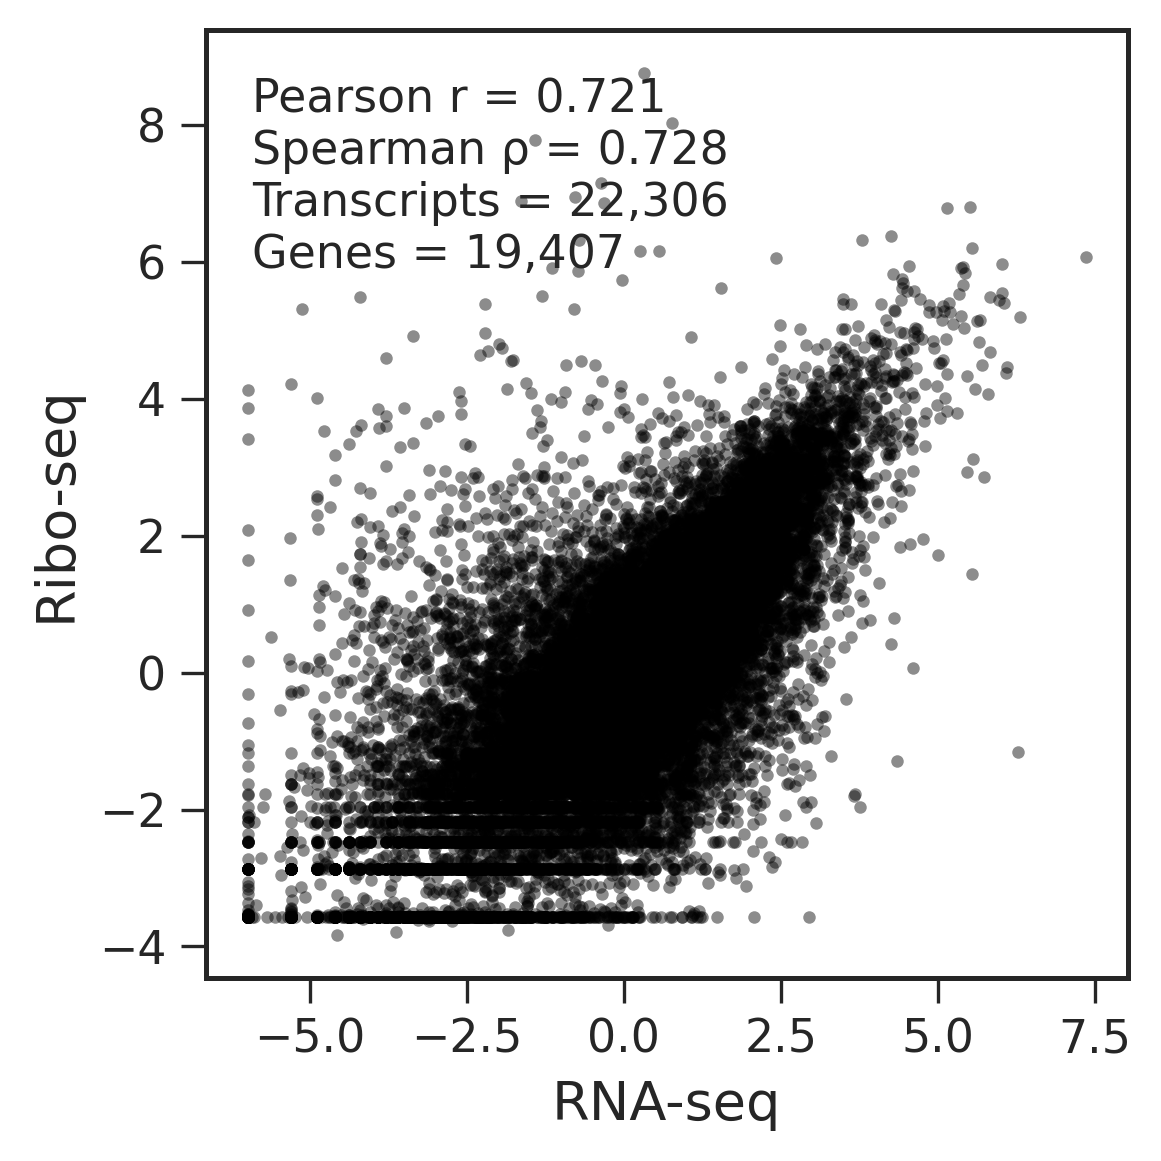

In [224]:

# ============================================
# Ribo-seq TPM vs RNA-seq TPM
# ============================================

x = master["rna_clr"]
y = master["ribo_clr"]

spearman_r, spearman_p = spearmanr(x, y)
pearson_r, pearson_p = pearsonr(x, y)

n_transcripts = master["transcript_id"].nunique()
n_genes = master["gene_id"].nunique()

fig, ax = make_fig(w =4, h= 4)

ax.scatter(
    x,
    y,
    s=9,
    color="black",
    alpha=0.45,
    linewidths=0,
)

# ax.set_title("Ribo-seq TPM vs RNA-seq TPM")
ax.set_xlabel("RNA-seq")
ax.set_ylabel("Ribo-seq")

text = (
    f"Pearson r = {pearson_r:.3f}\n"
    f"Spearman ρ = {spearman_r:.3f}\n"
    f"Transcripts = {n_transcripts:,}\n"
    f"Genes = {n_genes:,}\n"
)

ax.text(
    0.05,
    0.95,
    text,
    transform=ax.transAxes,
    ha="left",
    va="top",
)

plt.tight_layout()
plt.show()

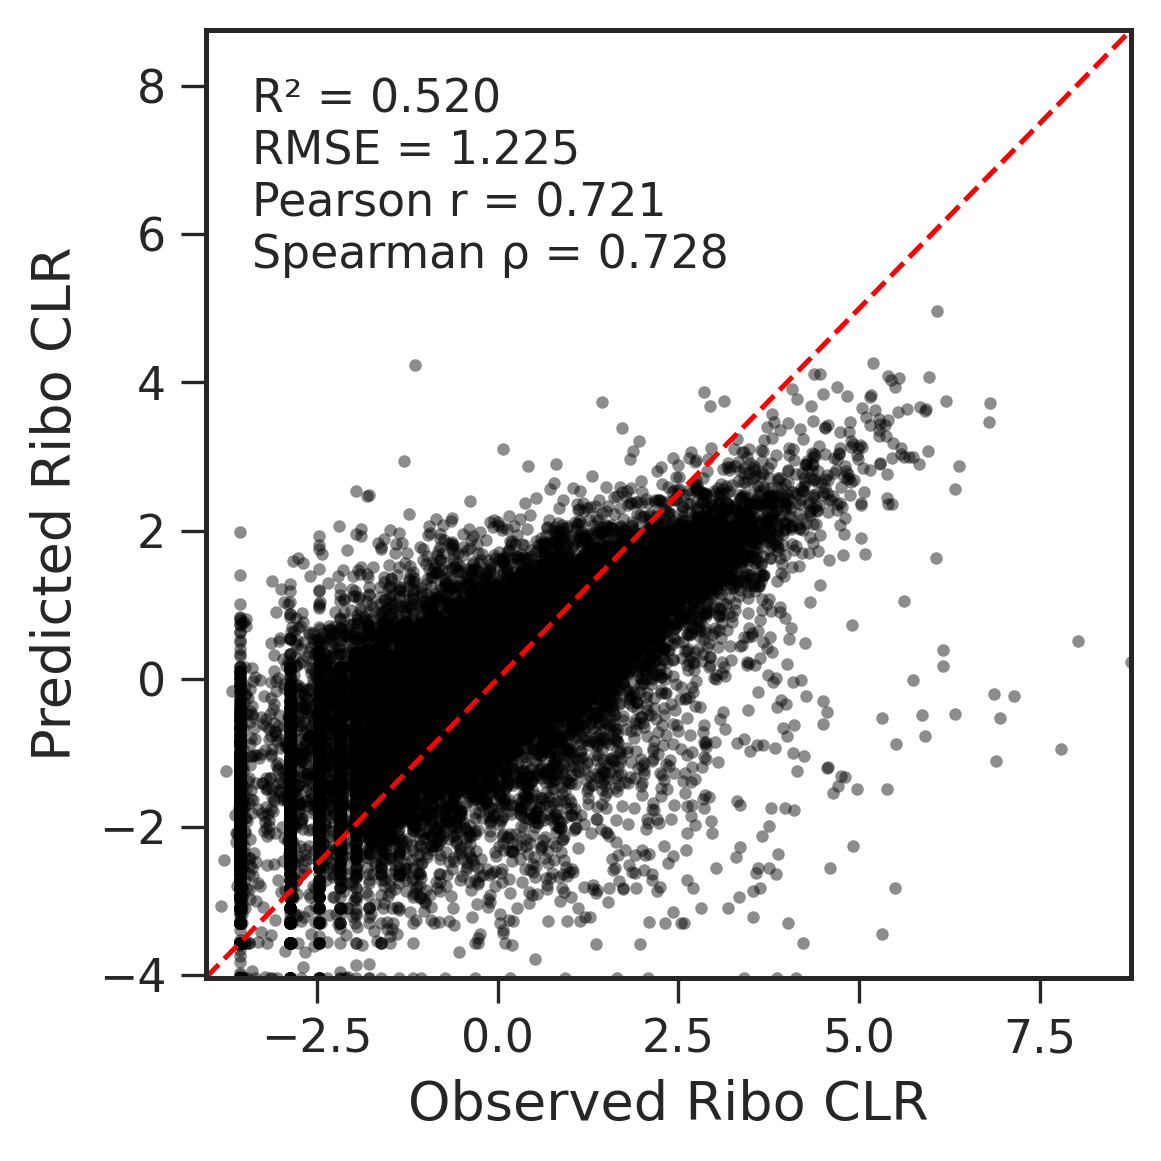

In [227]:
# ============================================
# Compositional model evaluation
# ============================================

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score, mean_squared_error

pred = model.predict(master[["rna_clr"]])

r2 = r2_score(
    master["ribo_clr"],
    pred,
)

rmse = np.sqrt(
    mean_squared_error(
        master["ribo_clr"],
        pred,
    )
)

pearson_r, _ = pearsonr(
    master["ribo_clr"],
    pred,
)

spearman_r, _ = spearmanr(
    master["ribo_clr"],
    pred,
)

fig, ax = make_fig(w=4, h=4)

ax.scatter(
    master["ribo_clr"],
    pred,
    s=9,
    color="black",
    alpha=0.45,
    linewidths=0,
)

# 1:1 reference line
lims = [
    min(master["ribo_clr"].min(), pred.min()),
    max(master["ribo_clr"].max(), pred.max()),
]

ax.plot(
    lims,
    lims,
    "--",
    color="red",
    linewidth=1.2,
)

ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("Observed Ribo CLR")
ax.set_ylabel("Predicted Ribo CLR")

text = (
    f"R² = {r2:.3f}\n"
    f"RMSE = {rmse:.3f}\n"
    f"Pearson r = {pearson_r:.3f}\n"
    f"Spearman ρ = {spearman_r:.3f}"
)

ax.text(
    0.05,
    0.95,
    text,
    transform=ax.transAxes,
    ha="left",
    va="top",
)

plt.tight_layout()
plt.show()

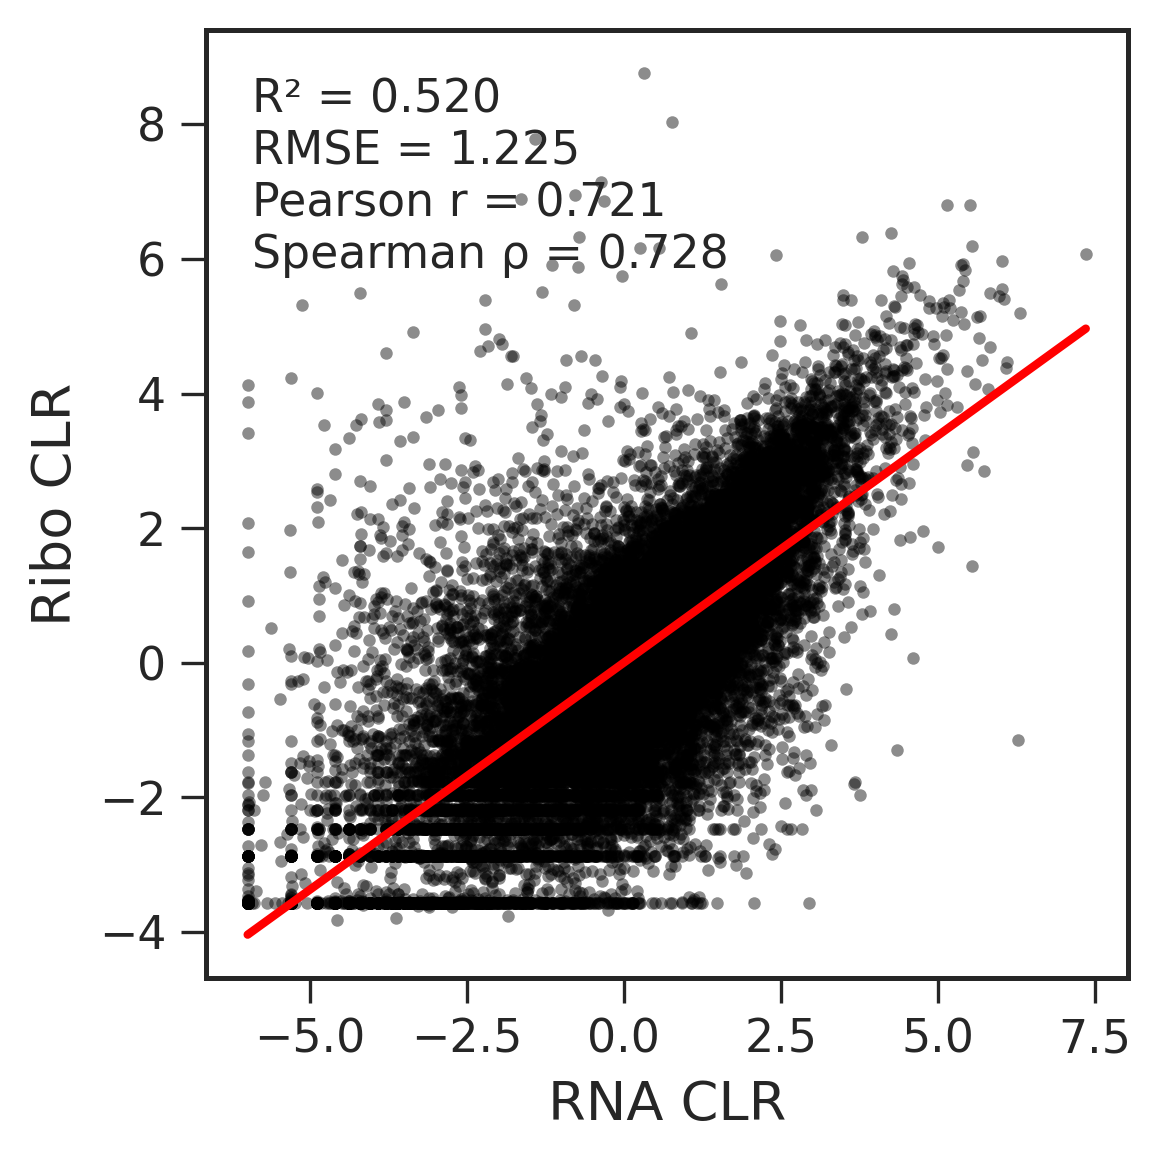

In [228]:
# ============================================
# Compositional linear model
# ============================================

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score, mean_squared_error

x = master["rna_clr"]
y = master["ribo_clr"]

pred = model.predict(master[["rna_clr"]])

r2 = r2_score(y, pred)

rmse = np.sqrt(
    mean_squared_error(
        y,
        pred,
    )
)

pearson_r, _ = pearsonr(x, y)
spearman_r, _ = spearmanr(x, y)

fig, ax = make_fig(w=4, h=4)

ax.scatter(
    x,
    y,
    s=9,
    color="black",
    alpha=0.45,
    linewidths=0,
)

# regression line
order = np.argsort(x)

ax.plot(
    x.iloc[order],
    pred[order],
    color="red",
    linewidth=2,
)

ax.set_xlabel("RNA CLR")
ax.set_ylabel("Ribo CLR")

text = (
    f"R² = {r2:.3f}\n"
    f"RMSE = {rmse:.3f}\n"
    f"Pearson r = {pearson_r:.3f}\n"
    f"Spearman ρ = {spearman_r:.3f}"
)

ax.text(
    0.05,
    0.95,
    text,
    transform=ax.transAxes,
    ha="left",
    va="top",
)

plt.tight_layout()
plt.show()

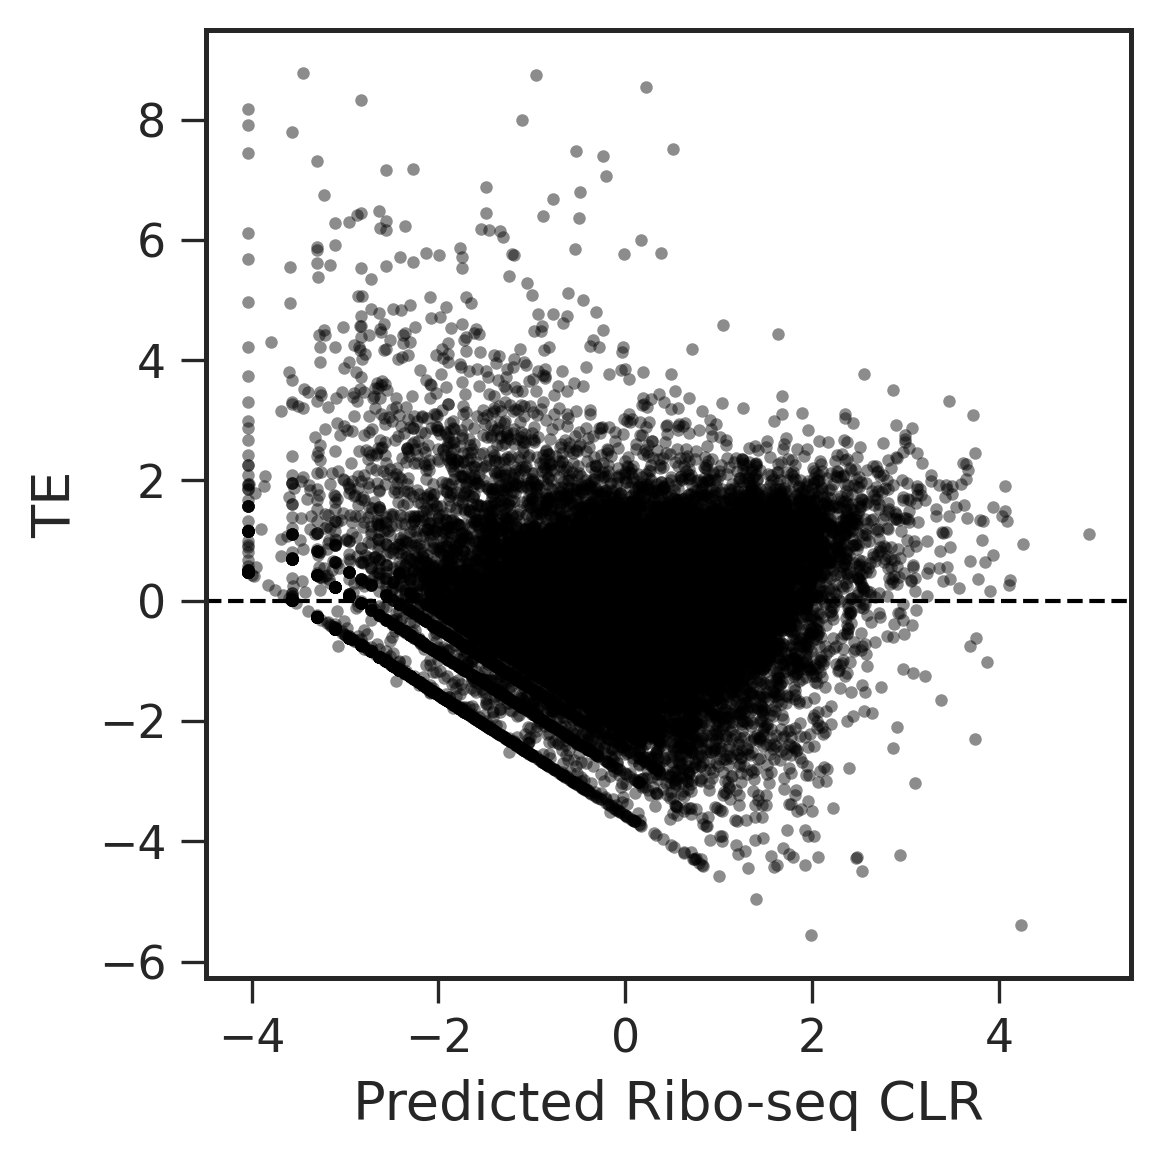

In [226]:
# ============================================
# Residual diagnostic
# ============================================

pred = model.predict(master[["rna_clr"]])

fig, ax = make_fig(w=4, h=4)

ax.scatter(
    pred,
    master["TE"],
    s=9,
    color="black",
    alpha=0.45,
    linewidths=0,
)

ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel("Predicted Ribo-seq CLR")
ax.set_ylabel("TE")

plt.tight_layout()
plt.show()

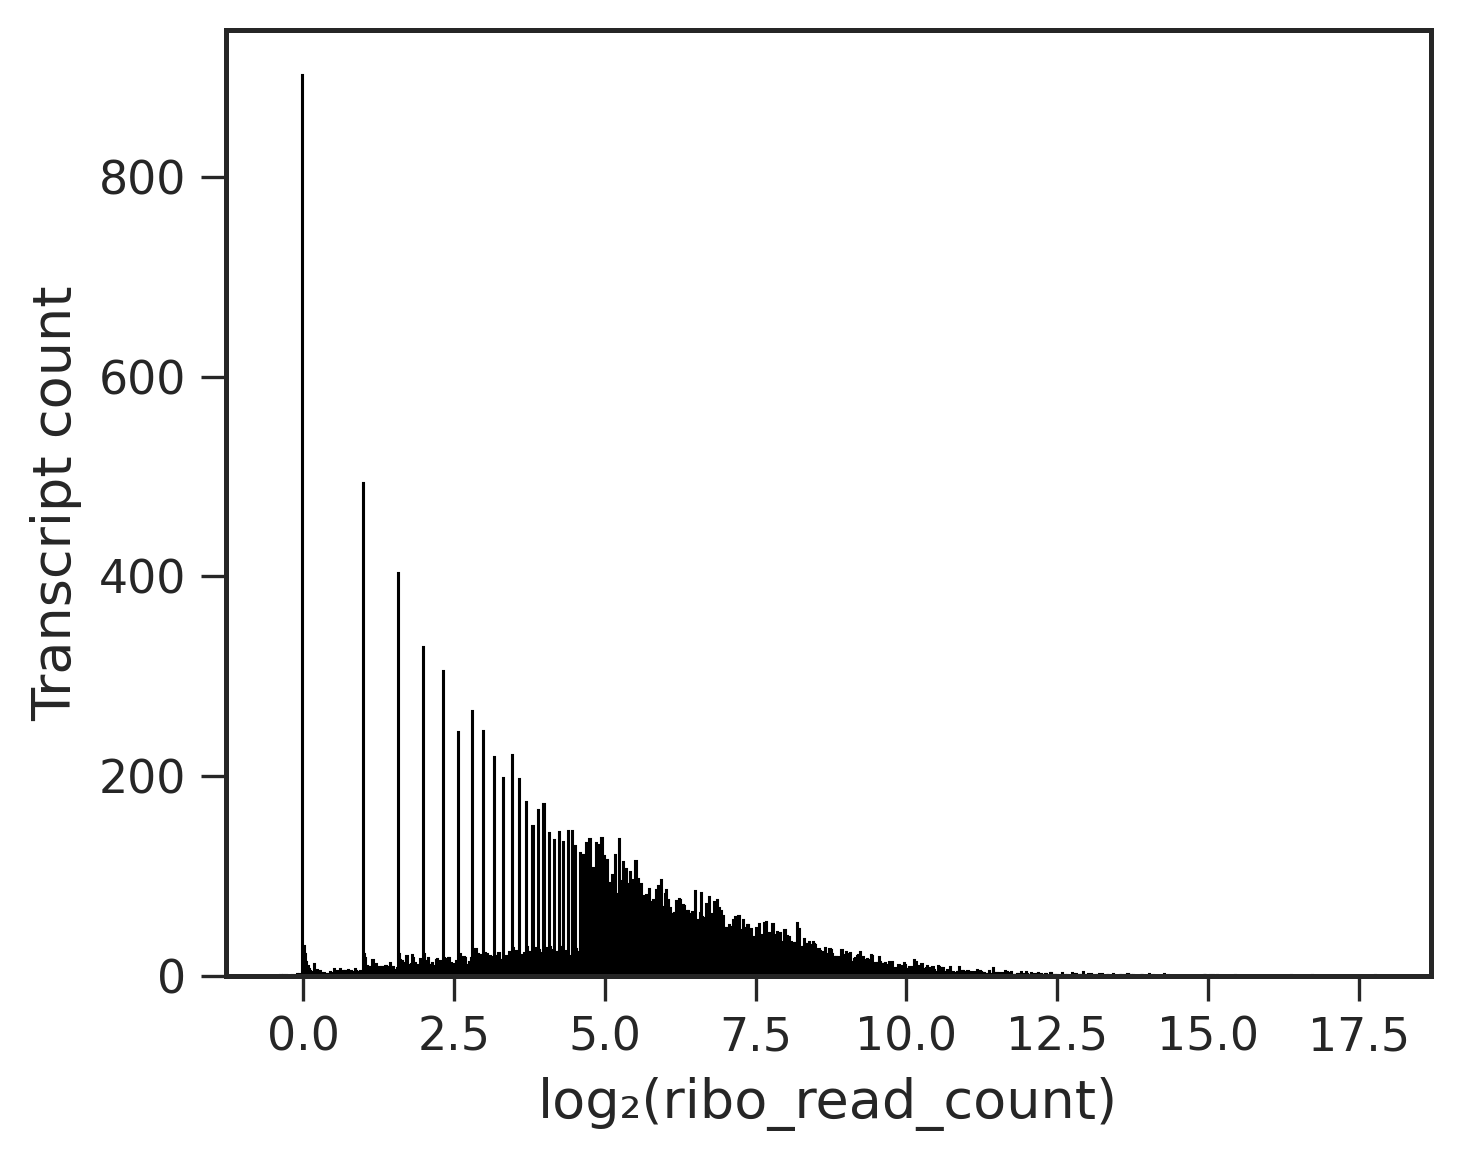

In [ ]:
# ============================================
# Histogram
# ============================================

metric = "ribo_read_count"
log = True

values = master[metric].copy()

if log:
    values = np.log2(values)

fig, ax = make_fig(w = 5, h=4)

ax.hist(
    values,
    bins=1000,
    edgecolor="black",
    linewidth=0.5,
)

xlabel = f"log₂({metric})" if log else metric

ax.set_xlabel(xlabel)
ax.set_ylabel("Transcript count")

plt.tight_layout()
plt.show()

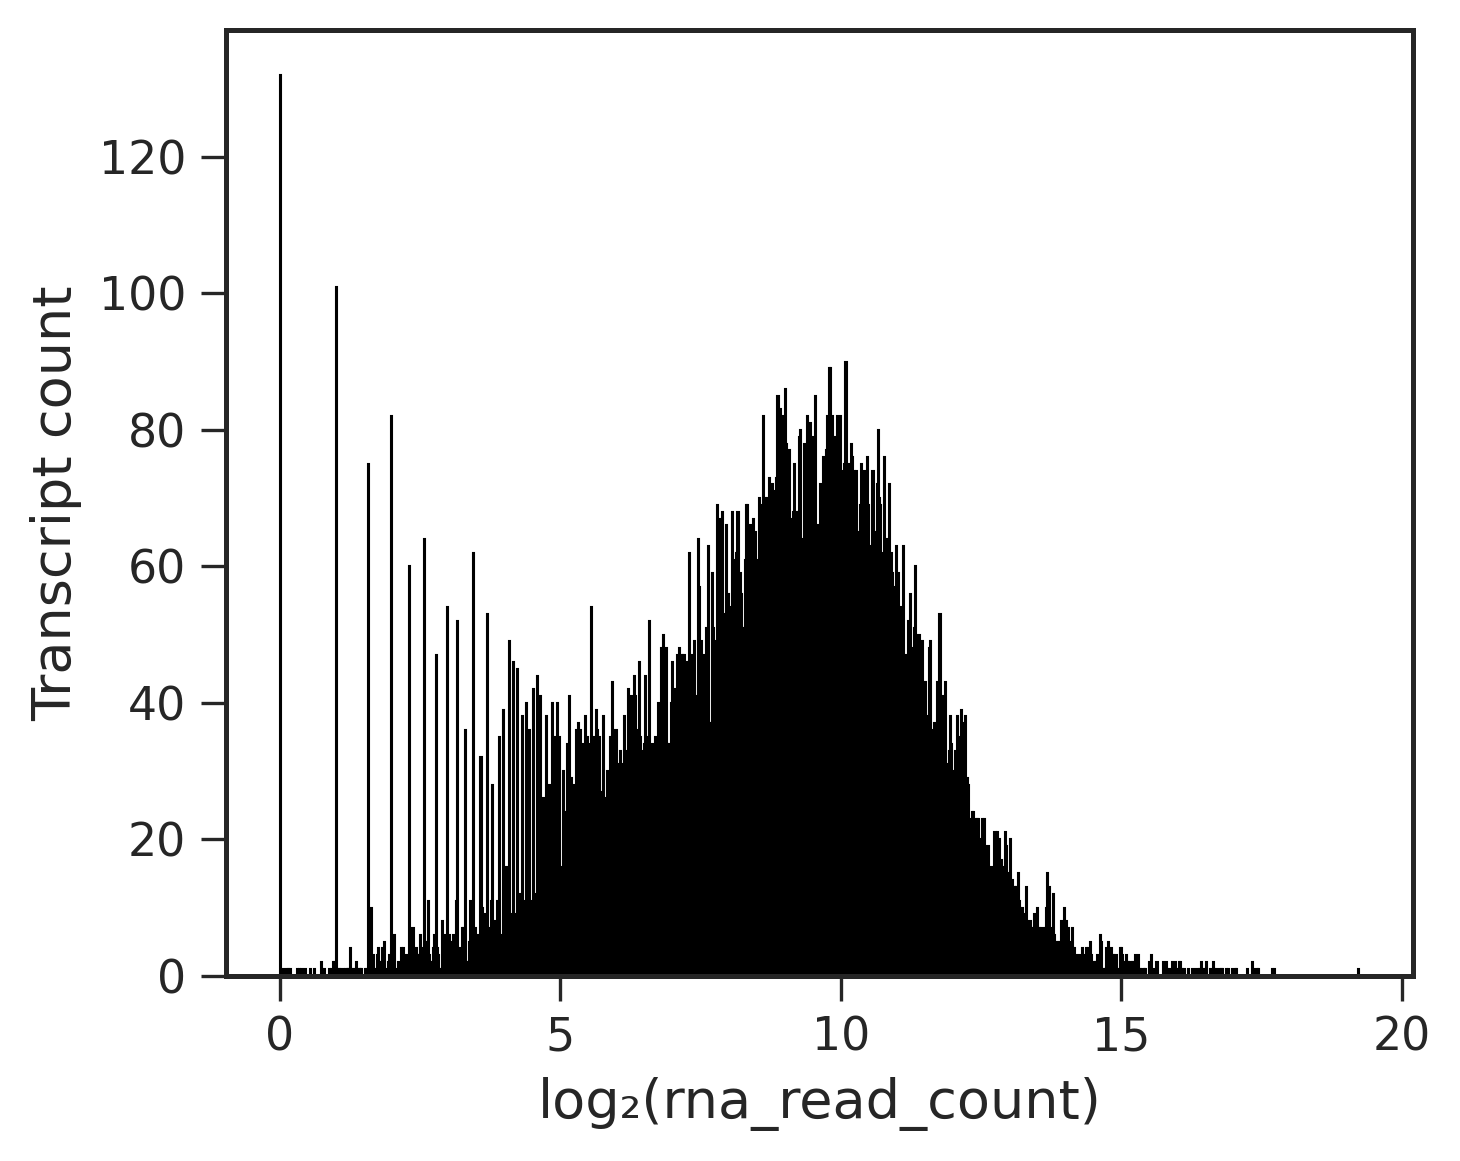

In [ ]:
# ============================================
# Histogram
# ============================================

metric = "rna_read_count"
log = True

values = master[metric].copy()

if log:
    values = np.log2(values)

fig, ax = make_fig(w = 5, h=4)

ax.hist(
    values,
    bins=1000,
    edgecolor="black",
    linewidth=0.5,
)

xlabel = f"log₂({metric})" if log else metric

ax.set_xlabel(xlabel)
ax.set_ylabel("Transcript count")

plt.tight_layout()
plt.show()

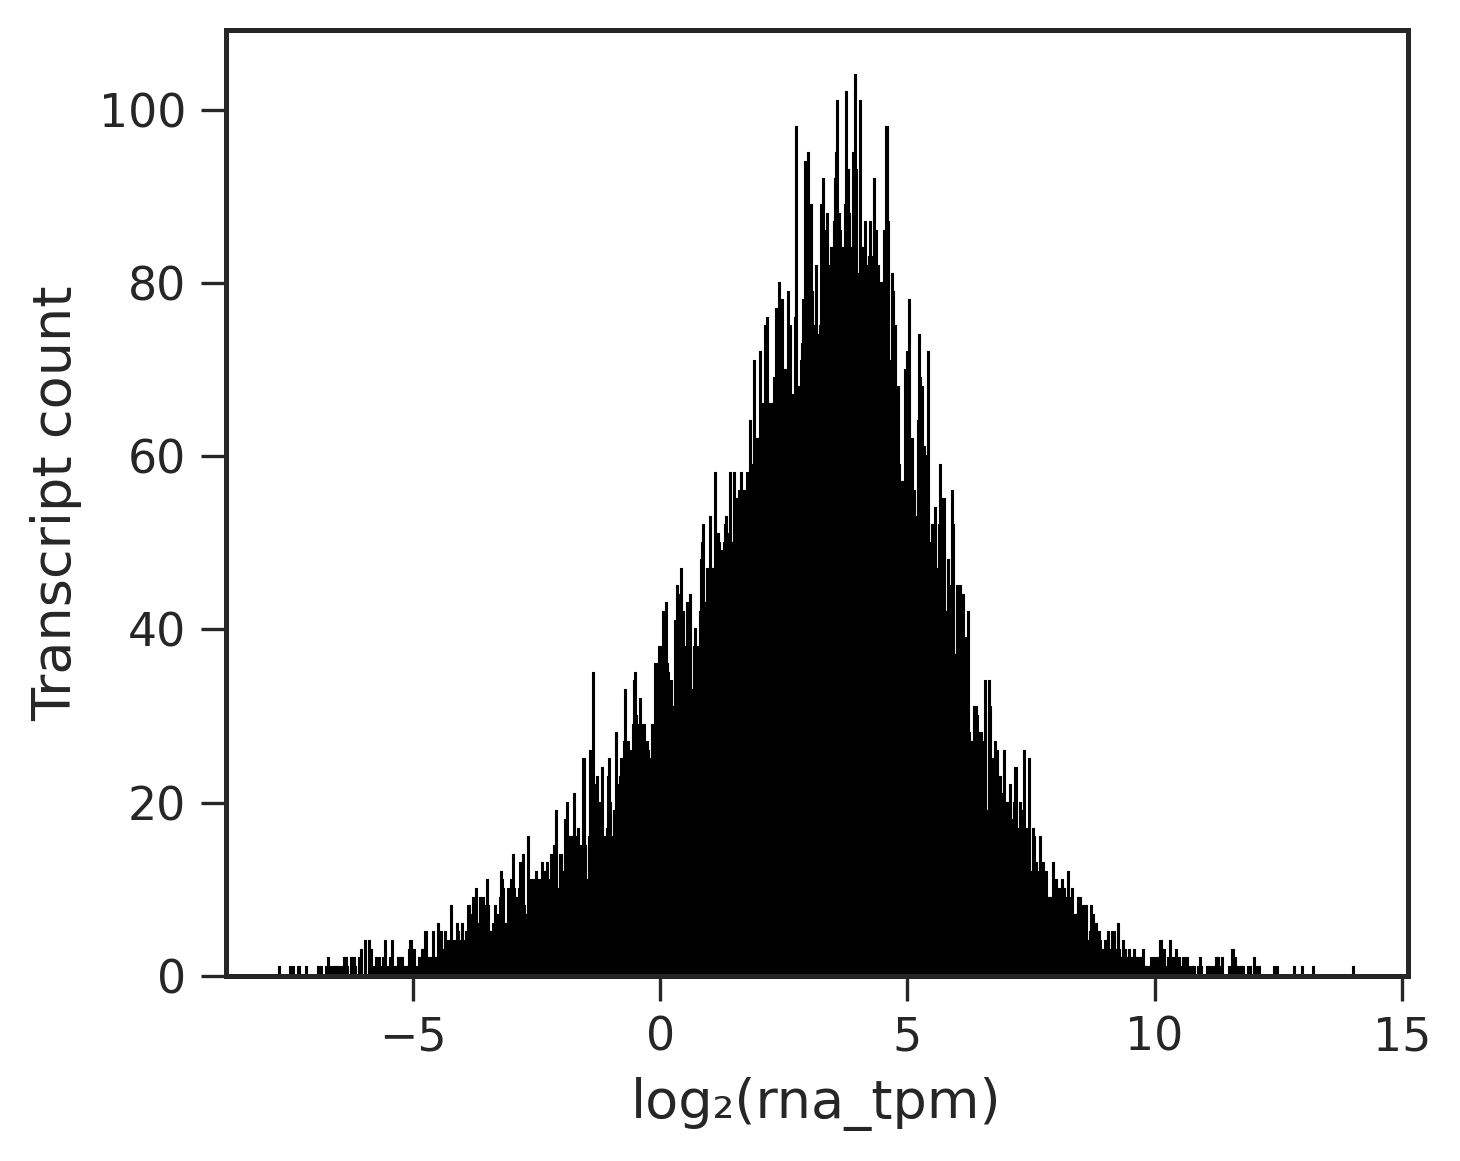

In [ ]:
# ============================================
# Histogram
# ============================================

metric = "rna_tpm"
log = True

values = master[metric].copy()

if log:
    values = np.log2(values)

fig, ax = make_fig(w = 5, h=4)

ax.hist(
    values,
    bins=1000,
    edgecolor="black",
    linewidth=0.5,
)

xlabel = f"log₂({metric})" if log else metric

ax.set_xlabel(xlabel)
ax.set_ylabel("Transcript count")

plt.tight_layout()
plt.show()

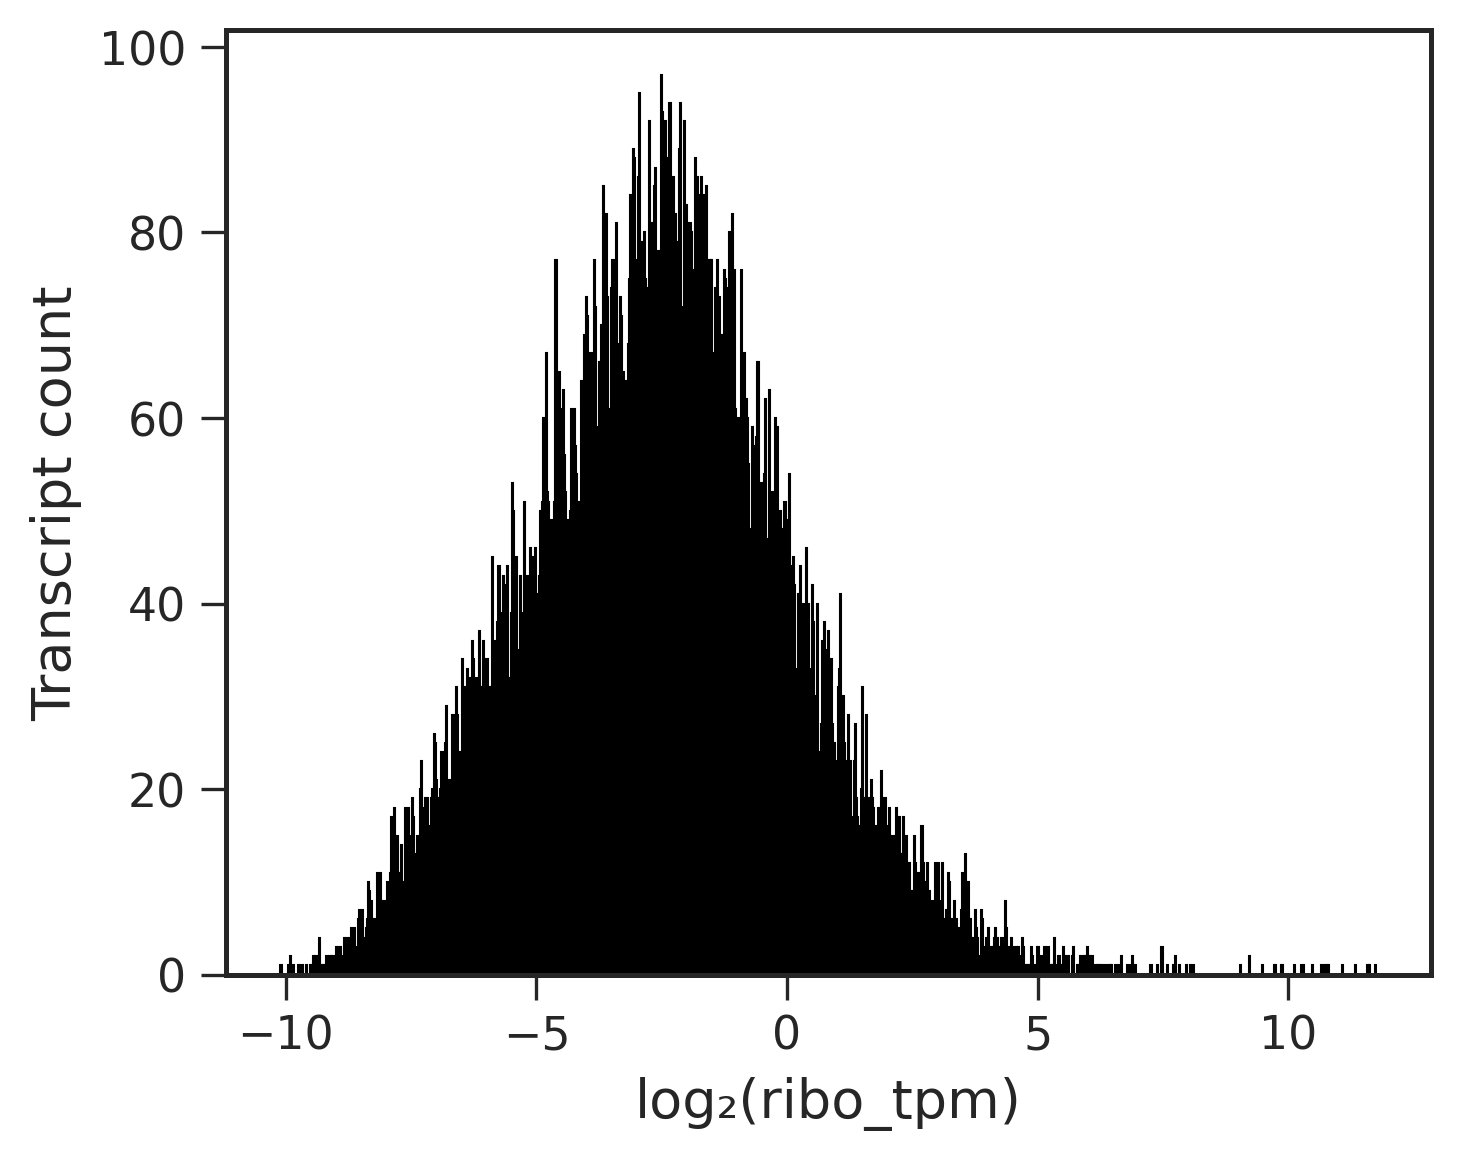

In [ ]:
# ============================================
# Histogram
# ============================================

metric = "ribo_tpm"
log = True

values = master[metric].copy()

if log:
    values = np.log2(values)

fig, ax = make_fig(w = 5, h=4)

ax.hist(
    values,
    bins=1000,
    edgecolor="black",
    linewidth=0.5,
)

xlabel = f"log₂({metric})" if log else metric

ax.set_xlabel(xlabel)
ax.set_ylabel("Transcript count")

plt.tight_layout()
plt.show()

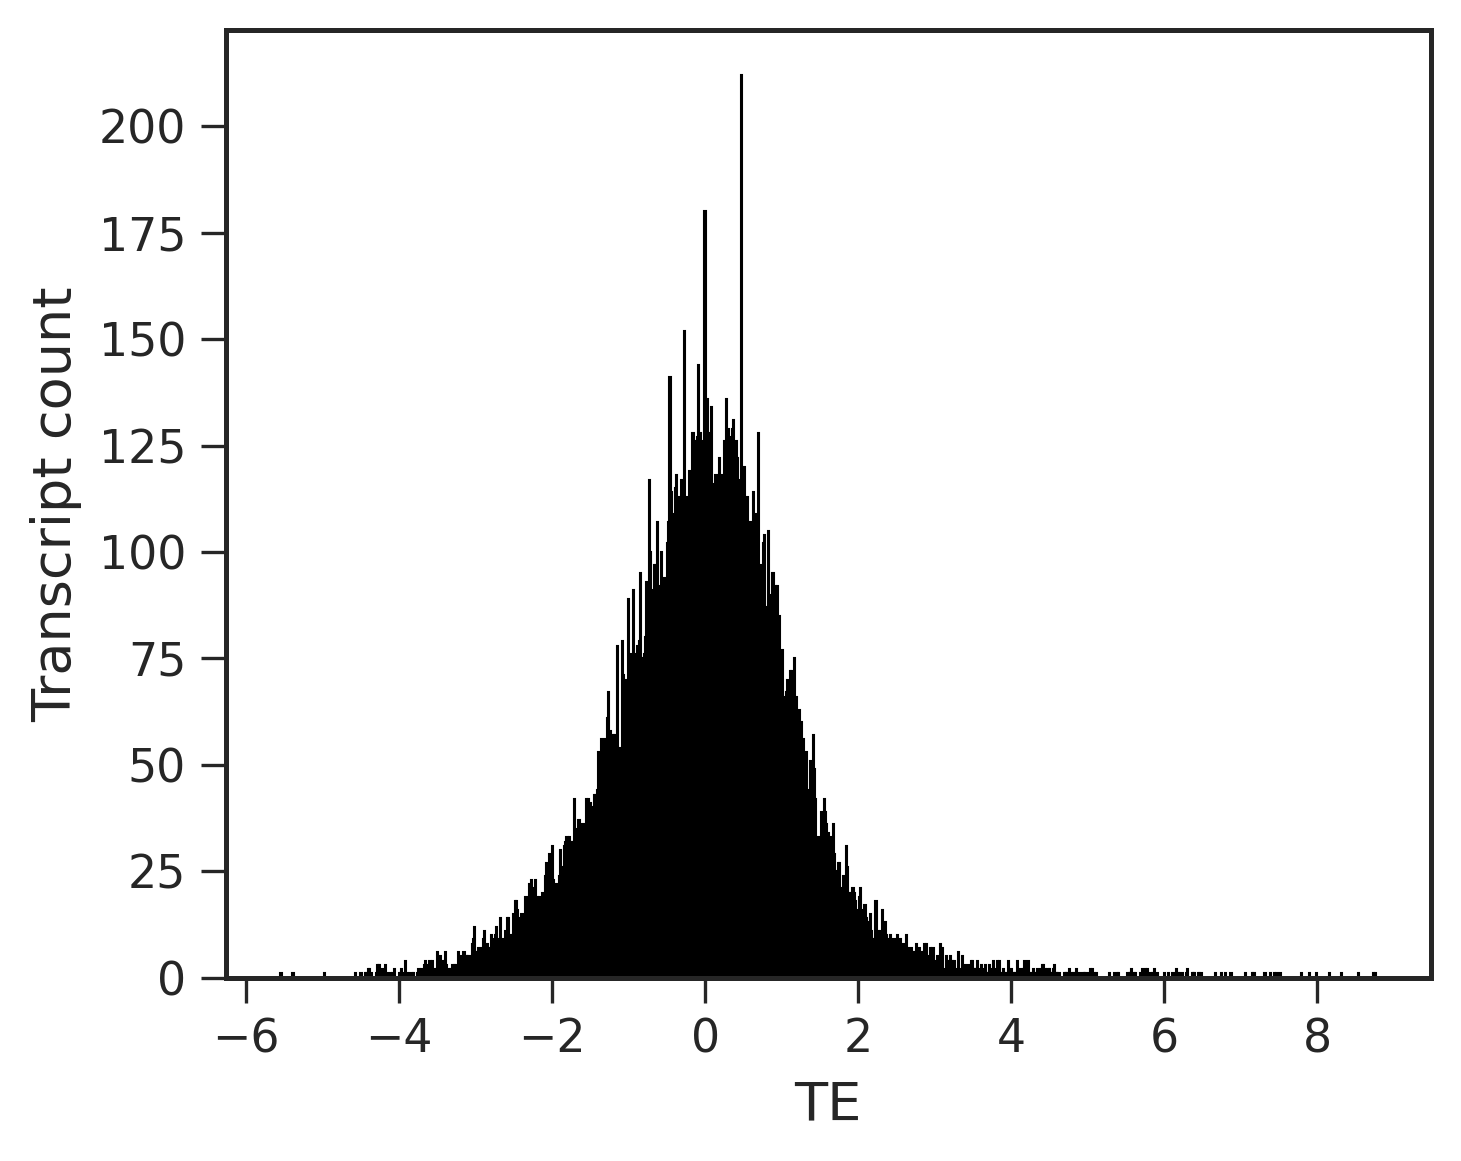

In [ ]:
# ============================================
# Histogram
# ============================================

metric = "TE"
log = False

values = master[metric].copy()

if log:
    values = np.log2(values)

fig, ax = make_fig(w = 5, h=4)

ax.hist(
    values,
    bins=1000,
    edgecolor="black",
    linewidth=0.5,
)

xlabel = f"log₂({metric})" if log else metric

ax.set_xlabel(xlabel)
ax.set_ylabel("Transcript count")

plt.tight_layout()
plt.show()

In [ ]:
# MIN_READ_COUNT = 50

# master = master.loc[
#     (master["rna_read_count"] > MIN_READ_COUNT) &
#     (master["ribo_read_count"] > MIN_READ_COUNT)
# ].copy()

# print(master.shape)
# display(master.head())
# display(master.describe())

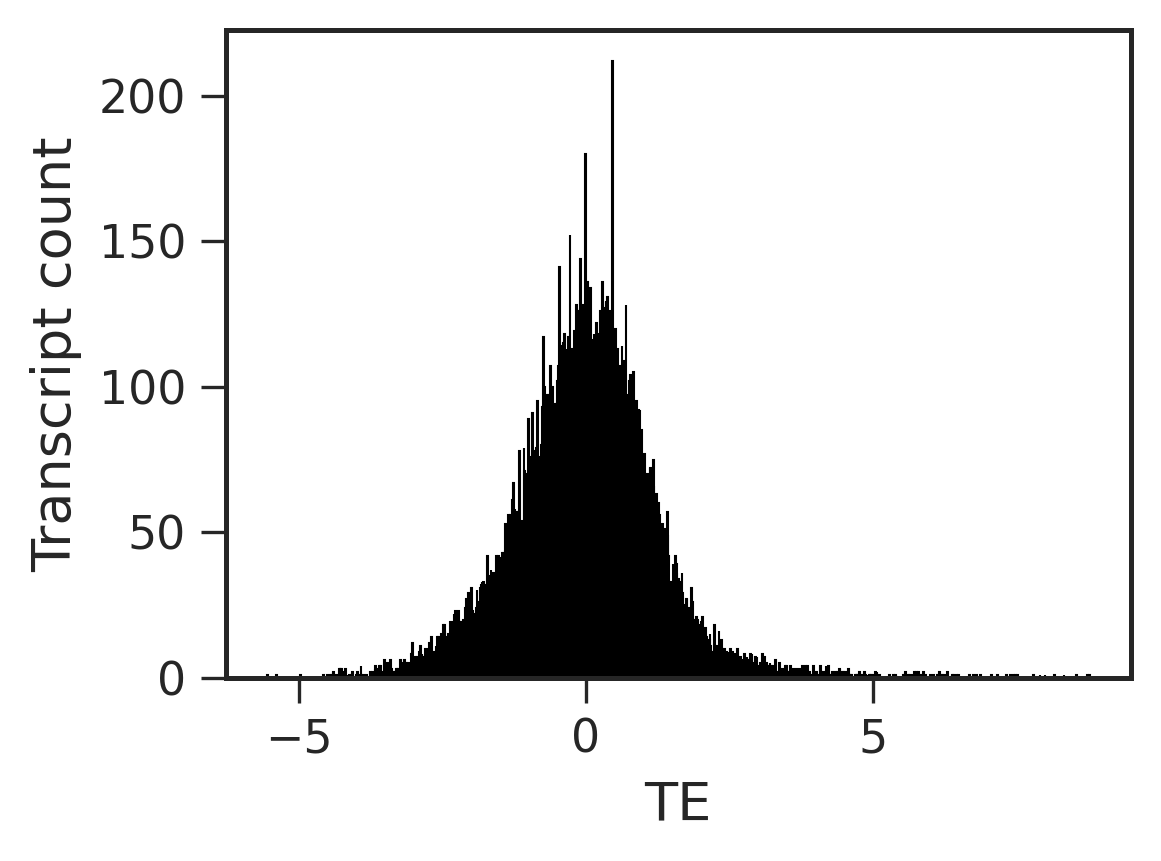

In [ ]:
# ============================================
# Histogram
# ============================================

metric = "TE"
log = False

values = master[metric].copy()

if log:
    values = np.log2(values)

fig, ax = make_fig(w = 4, h=3)

ax.hist(
    values,
    bins=1000,
    edgecolor="black",
    linewidth=0.5,
)

xlabel = f"log₂({metric})" if log else metric

ax.set_xlabel(xlabel)
ax.set_ylabel("Transcript count")

plt.tight_layout()
plt.show()

In [ ]:
summary = pd.DataFrame({
    "Metric": [
        "Total annotated transcripts",
        "Quantified transcripts",
        "Genes",
        "Pearson (RNA vs Ribo)",
        "Spearman (RNA vs Ribo)",
        "Mean TE",
        "SD TE",
    ],
    "Value": [
        f"{len(tx2gene):,}",
        f"{master.shape[0]:,}",
        f"{master['gene_id'].nunique():,}",
        f"{pearson_r:.3f}",
        f"{spearman_r:.3f}",
        f"{master['TE'].mean():.3f}",
        f"{master['TE'].std():.3f}",
    ]
})

display(summary)

,Metric,Value
0,Total annotated transcripts,"59,478"
1,Quantified transcripts,"22,306"
2,Genes,"19,407"
3,Pearson (RNA vs Ribo),0.721
4,Spearman (RNA vs Ribo),0.728
5,Mean TE,-0.000
6,SD TE,1.225


In [230]:
# ============================================
# Build transcript-region SAF files
# ============================================

from pathlib import Path
import gzip
import re


# Repository resources
REPO_DIR = Path("/home/ha-ibnu/Code/processing/riboseq")
GFF3 = REPO_DIR / "refs/at.gff3.gz"

# nf-core/riboseq outputs
NFCORE_DIR = Path("/mnt/d/Ibnu/riboseq/AT/nfcore/full")

RNA_BAM = (
    NFCORE_DIR
    / "alignment/star/sorted/RNA_FULL.genome.sorted.bam"
)

RIBO_BAM = (
    NFCORE_DIR
    / "alignment/star/sorted/RIBO_FULL.genome.sorted.bam"
)

# Output inside the repository
OUTDIR = (
    REPO_DIR
    / "postprocess/arabidopsis_thaliana/regions"
)

OUTDIR.mkdir(parents=True, exist_ok=True)


# Confirm that required files exist
for path in [GFF3, RNA_BAM, RIBO_BAM]:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")


feature_map = {
    "five_prime_UTR": OUTDIR / "five_prime_UTR.saf",
    "CDS": OUTDIR / "CDS.saf",
    "three_prime_UTR": OUTDIR / "three_prime_UTR.saf",
}


handles = {
    feature: path.open("w")
    for feature, path in feature_map.items()
}


try:
    # SAF header required by featureCounts
    for handle in handles.values():
        handle.write("GeneID\tChr\tStart\tEnd\tStrand\n")

    with gzip.open(GFF3, "rt") as fh:
        for line in fh:

            if line.startswith("#"):
                continue

            fields = line.rstrip().split("\t")

            if len(fields) != 9:
                continue

            (
                chrom,
                source,
                feature,
                start,
                end,
                score,
                strand,
                phase,
                attributes,
            ) = fields

            if feature not in feature_map:
                continue

            parent_match = re.search(
                r"(?:^|;)Parent=([^;]+)",
                attributes,
            )

            if parent_match is None:
                continue

            transcript_ids = parent_match.group(1).split(",")

            for transcript_id in transcript_ids:
                handles[feature].write(
                    f"{transcript_id}\t"
                    f"{chrom}\t"
                    f"{start}\t"
                    f"{end}\t"
                    f"{strand}\n"
                )

finally:
    for handle in handles.values():
        handle.close()


print("Input annotation:")
print(GFF3)

print("\nRNA BAM:")
print(RNA_BAM)

print("\nRibo BAM:")
print(RIBO_BAM)

print("\nCreated SAF files:")
for path in feature_map.values():
    print(path)

Input annotation:
/home/ha-ibnu/Code/processing/riboseq/refs/at.gff3.gz

RNA BAM:
/mnt/d/Ibnu/riboseq/AT/nfcore/full/alignment/star/sorted/RNA_FULL.genome.sorted.bam

Ribo BAM:
/mnt/d/Ibnu/riboseq/AT/nfcore/full/alignment/star/sorted/RIBO_FULL.genome.sorted.bam

Created SAF files:
/home/ha-ibnu/Code/processing/riboseq/postprocess/arabidopsis_thaliana/regions/five_prime_UTR.saf
/home/ha-ibnu/Code/processing/riboseq/postprocess/arabidopsis_thaliana/regions/CDS.saf
/home/ha-ibnu/Code/processing/riboseq/postprocess/arabidopsis_thaliana/regions/three_prime_UTR.saf


In [231]:
# ============================================
# Extract transcript-region sequences
# ============================================

from pathlib import Path
import re
import pandas as pd


TRANSCRIPT_FASTA = Path(
    "/home/ha-ibnu/Code/processing/riboseq/"
    "postprocess/arabidopsis_thaliana/sequences/transcripts.fa"
)


records = []

transcript_id = None
cds_start = None
cds_end = None
sequence_parts = []


def save_record(
    transcript_id,
    cds_start,
    cds_end,
    sequence_parts,
):
    if transcript_id is None:
        return None

    sequence = "".join(sequence_parts).upper()

    if cds_start is None or cds_end is None:
        utr5_seq = None
        cds_seq = None
        utr3_seq = None
    else:
        # FASTA header coordinates are 1-based and inclusive
        utr5_seq = sequence[:cds_start - 1]
        cds_seq = sequence[cds_start - 1:cds_end]
        utr3_seq = sequence[cds_end:]

    return {
        "transcript_id": transcript_id,
        "mrna_seq": sequence,
        "utr5_seq": utr5_seq,
        "cds_seq": cds_seq,
        "utr3_seq": utr3_seq,
        "mrna_length": len(sequence),
        "utr5_length": len(utr5_seq) if utr5_seq is not None else None,
        "cds_length": len(cds_seq) if cds_seq is not None else None,
        "utr3_length": len(utr3_seq) if utr3_seq is not None else None,
    }


with TRANSCRIPT_FASTA.open() as handle:
    for line in handle:
        line = line.strip()

        if line.startswith(">"):
            record = save_record(
                transcript_id,
                cds_start,
                cds_end,
                sequence_parts,
            )

            if record is not None:
                records.append(record)

            header = line[1:]
            transcript_id = header.split()[0]

            match = re.search(r"CDS=(\d+)-(\d+)", header)

            if match:
                cds_start = int(match.group(1))
                cds_end = int(match.group(2))
            else:
                cds_start = None
                cds_end = None

            sequence_parts = []

        else:
            sequence_parts.append(line)


record = save_record(
    transcript_id,
    cds_start,
    cds_end,
    sequence_parts,
)

if record is not None:
    records.append(record)


transcript_regions = pd.DataFrame(records)

print(transcript_regions.shape)

display(
    transcript_regions[
        [
            "transcript_id",
            "mrna_length",
            "utr5_length",
            "cds_length",
            "utr3_length",
        ]
    ].head()
)

(59478, 9)


,transcript_id,mrna_length,utr5_length,cds_length,utr3_length
0,AT1G01010.1,1688,129.0,1290.0,269.0
1,AT1G01020.2,1087,71.0,576.0,440.0
2,AT1G01020.6,944,189.0,315.0,440.0
3,AT1G01020.1,1329,464.0,738.0,127.0
4,AT1G01020.3,1420,582.0,711.0,127.0


In [232]:
master = master.merge(
    transcript_regions,
    on="transcript_id",
    how="left",
)

print(master.shape)

display(master.head())

(22306, 18)


,transcript_id,gene_id,gene_name,ribo_read_count,rna_read_count,ribo_tpm,rna_tpm,rna_clr,ribo_clr,TE,mrna_seq,utr5_seq,cds_seq,utr3_seq,mrna_length,utr5_length,cds_length,utr3_length
0,AT1G01010.1,AT1G01010,AT1G01010,24.00,157.000,0.107730,2.876792,-0.930637,-0.390050,0.238028,AAATTATTAGATATACCAAACCAGAGAAAACAAATACATAATCGGA...,AAATTATTAGATATACCAAACCAGAGAAAACAAATACATAATCGGA...,ATGGAGGATCAAGTTGGGTTTGGGTTCCGTCCGAACGACGAGGAGC...,GAGGTCAAATCGGATTCTTGCTCAAAATTTGTATTTCTTAGAATGT...,1688,129.0,1290.0,269.0
1,AT1G01020.2,AT1G01020,AT1G01020,14.00,211.134,0.107966,6.646622,-0.634390,-0.929047,-0.500903,AGACCCGGACTCTAATTGCTCCGTATTCTTCTTCTCTTGAGAGAGA...,AGACCCGGACTCTAATTGCTCCGTATTCTTCTTCTCTTGAGAGAGA...,ATGGCGGCGAGTGAACACAGATGCGTGGGATGTGGTTTTAGGGTAA...,ATCATGCACTAAAGTTTCTTGTATTGATTAAACATGGTGTTATGTC...,1087,71.0,576.0,440.0
2,AT1G01030.2,AT1G01030,AT1G01030,7.00,19.582,0.028489,0.325320,-3.012272,-1.622194,0.410760,ATATCATTCATGGGCCCCTACGCATTACTCGGTACCAATCTCGCTC...,ATATCATTCATGGGCCCCTACGCATTACTCGGTACCAATCTCGCTC...,ATGGATCTATCCCTGGCTCCGACAACAACAACAAGTTCCGACCAAG...,GAAGTTTCATCATCTTCTTGTTTTGAATCTCTCTTTATATTGTTTC...,1836,613.0,1008.0,215.0
3,AT1G01040.1,AT1G01040,AT1G01040,48.00,2345.008,0.051416,10.253755,1.773161,0.303097,-0.893593,GTGGAAAACAGACCAGAAGAGAGAGGAAGACGAAGAGAGAAACAGA...,GTGGAAAACAGACCAGAAGAGAGAGGAAGACGAAGAGAGAAACAGA...,ATGGTAATGGAGGATGAGCCTAGAGAAGCCACAATAAAGCCTTCTT...,TTCTTTTACTCTCTTCAACGAGATGTAGTCATTACATTTTAAACCT...,6276,398.0,5730.0,148.0
4,AT1G01050.1,AT1G01050,AT1G01050,197.02,2517.218,1.709312,89.148807,1.844027,1.715201,0.470685,TCCGTATATCTCGGTGGTGACTCATATATACATTTTACAATCACTT...,TCCGTATATCTCGGTGGTGACTCATATATACATTTTACAATCACTT...,ATGAGTGAAGAAACTAAAGATAACCAGAGGCTGCAGCGACCAGCTC...,AGCTTCTCCTCAGAAGATTTCTGCAGCATCTATGTTTCTGTTACTT...,994,143.0,639.0,212.0


In [234]:
# ============================================
# P-site distribution across transcript regions
# ============================================

import pandas as pd

psite = pd.read_csv(
    "/mnt/d/Ibnu/riboseq/AT/nfcore/full/ribowaltz/RIBO_FULL.psite.tsv.gz",
    sep="\t",
)

region_counts = (
    psite["psite_region"]
    .value_counts()
    .rename_axis("Region")
    .reset_index(name="P_sites")
)

region_counts["Percentage"] = (
    region_counts["P_sites"]
    / region_counts["P_sites"].sum()
    * 100
)

display(region_counts)

,Region,P_sites,Percentage
0,cds,7670458,95.643768
1,5utr,192951,2.405927
2,3utr,156411,1.950306


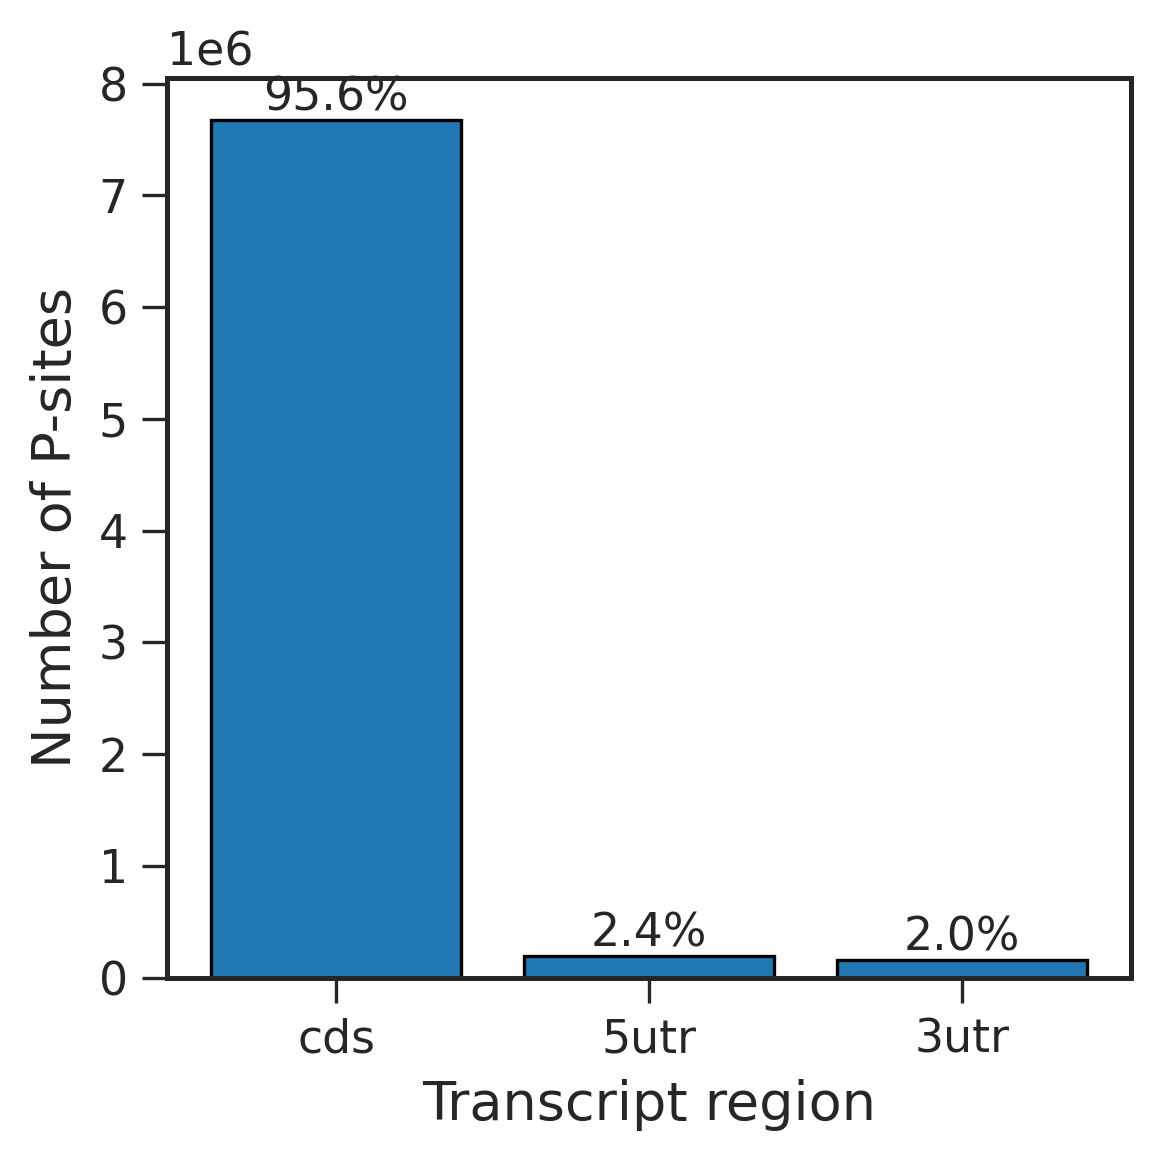

In [235]:

fig, ax = make_fig(w=4, h=4)

bars = ax.bar(
    region_counts["Region"],
    region_counts["P_sites"],
    edgecolor="black",
    linewidth=0.8,
)

for bar, pct in zip(bars, region_counts["Percentage"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_xlabel("Transcript region")
ax.set_ylabel("Number of P-sites")

plt.tight_layout()
plt.show()

In [236]:
psite = pd.read_csv(
    "/mnt/d/Ibnu/riboseq/AT/nfcore/full/ribowaltz/RIBO_FULL.psite.tsv.gz",
    sep="\t",
)

# Use only P-sites located inside the CDS
cds_psite = psite.loc[
    psite["psite_region"].str.lower() == "cds"
].copy()

# Position relative to CDS start:
# frame 0 = first nucleotide of a codon
# frame 1 = second nucleotide
# frame 2 = third nucleotide
cds_psite["frame"] = cds_psite["psite_from_start"] % 3

frame_counts = (
    cds_psite["frame"]
    .value_counts()
    .reindex([0, 1, 2], fill_value=0)
    .rename_axis("Frame")
    .reset_index(name="P_sites")
)

frame_counts["Percentage"] = (
    frame_counts["P_sites"]
    / frame_counts["P_sites"].sum()
    * 100
)

frame_counts["Frame_label"] = (
    frame_counts["Frame"]
    .map({
        0: "Frame 0",
        1: "Frame 1",
        2: "Frame 2",
    })
)

display(frame_counts)

,Frame,P_sites,Percentage,Frame_label
0,0,5405259,70.468530,Frame 0
1,1,1013202,13.209146,Frame 1
2,2,1251997,16.322324,Frame 2


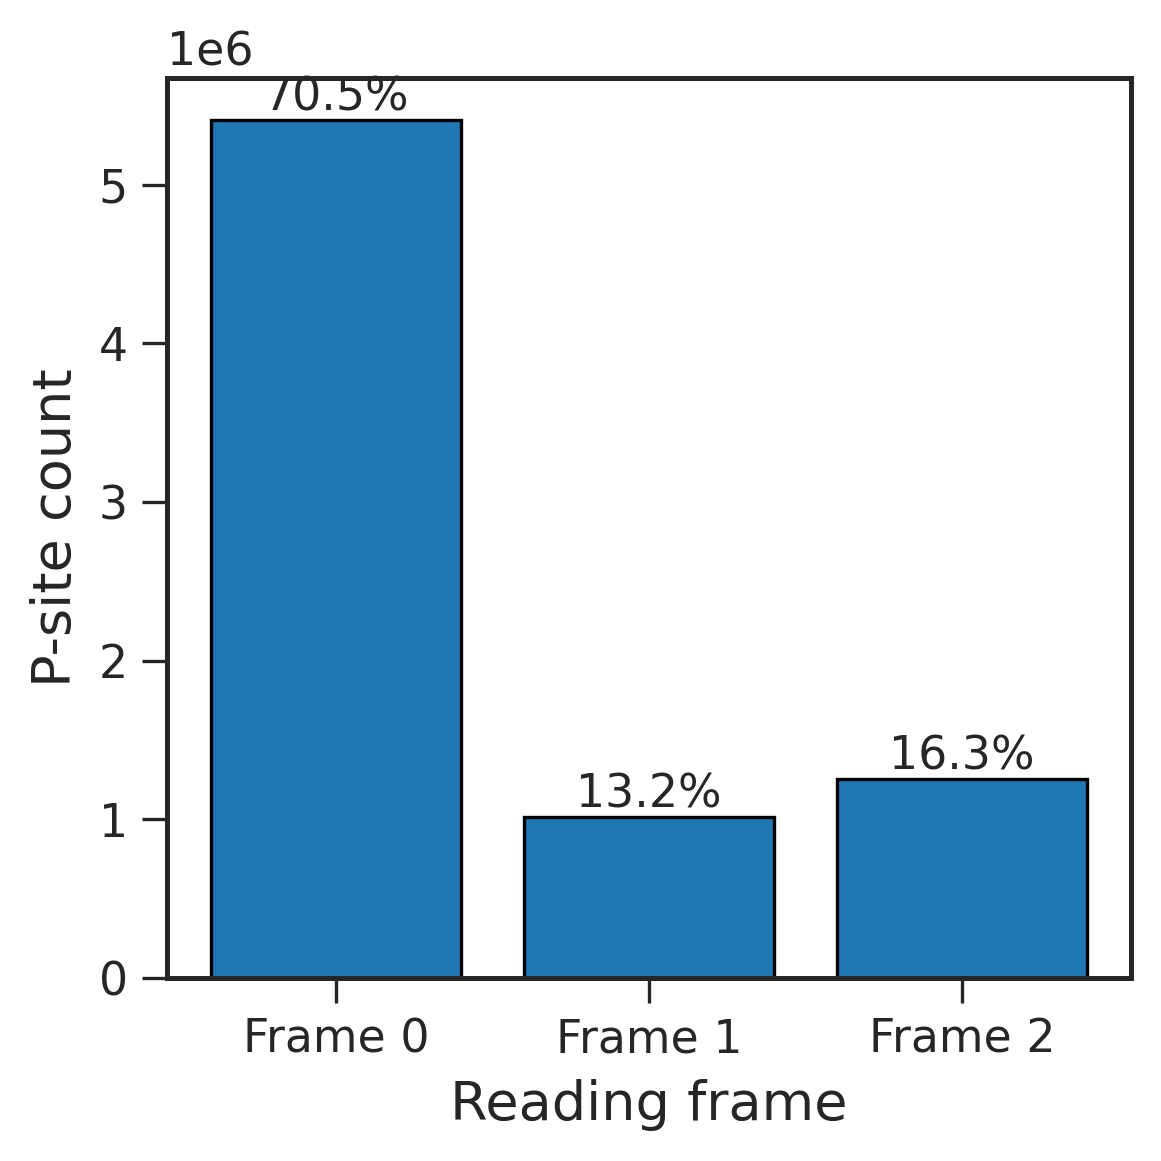

In [237]:

fig, ax = make_fig(w=4, h=4)

bars = ax.bar(
    frame_counts["Frame_label"],
    frame_counts["P_sites"],
    edgecolor="black",
    linewidth=0.8,
)

for bar, pct in zip(bars, frame_counts["Percentage"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_xlabel("Reading frame")
ax.set_ylabel("P-site count")

plt.tight_layout()
plt.show()

,Length,P_sites,Percentage
0,20,21578,0.105459
1,21,47867,0.233942
2,22,92565,0.452396
3,23,157230,0.768435
4,24,225951,1.104297
5,25,483863,2.364799
6,26,970774,4.744494
7,27,1586552,7.754005
8,28,4311881,21.073589
9,29,6584339,32.179843


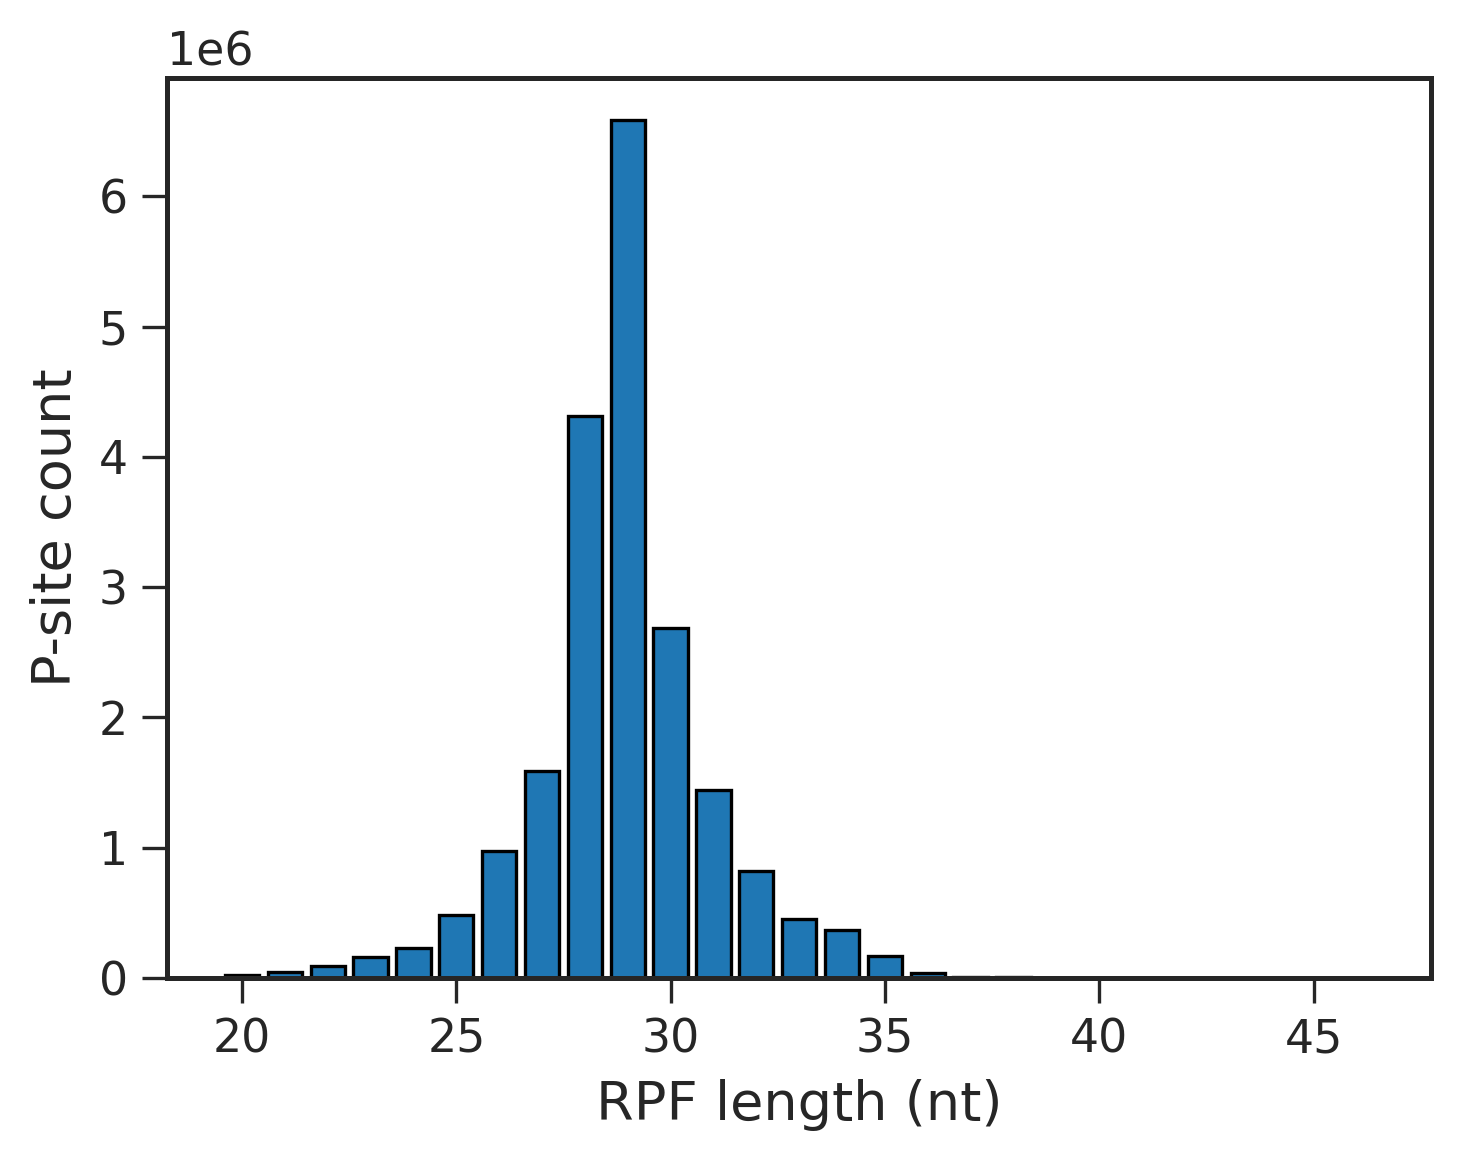

In [242]:
# ============================================
# RPF length distribution
# ============================================

length_counts = (
    psite["length"]
    .value_counts()
    .sort_index()
    .rename_axis("Length")
    .reset_index(name="P_sites")
)

length_counts["Percentage"] = (
    length_counts["P_sites"]
    / length_counts["P_sites"].sum()
    * 100
)

display(length_counts)

fig, ax = make_fig(w=5, h=4)

ax.bar(
    length_counts["Length"],
    length_counts["P_sites"],
    edgecolor="black",
    linewidth=0.8,
)

ax.set_xlabel("RPF length (nt)")
ax.set_ylabel("P-site count")

plt.tight_layout()
plt.show()

frame,0,1,2
length,,,
20,1920,682,229
21,5940,859,335
22,8961,3067,526
23,10757,4089,1162
24,25114,4879,2763
25,48011,12590,5138
26,79870,30235,10339
27,225084,41200,56605
28,2065704,124499,74644


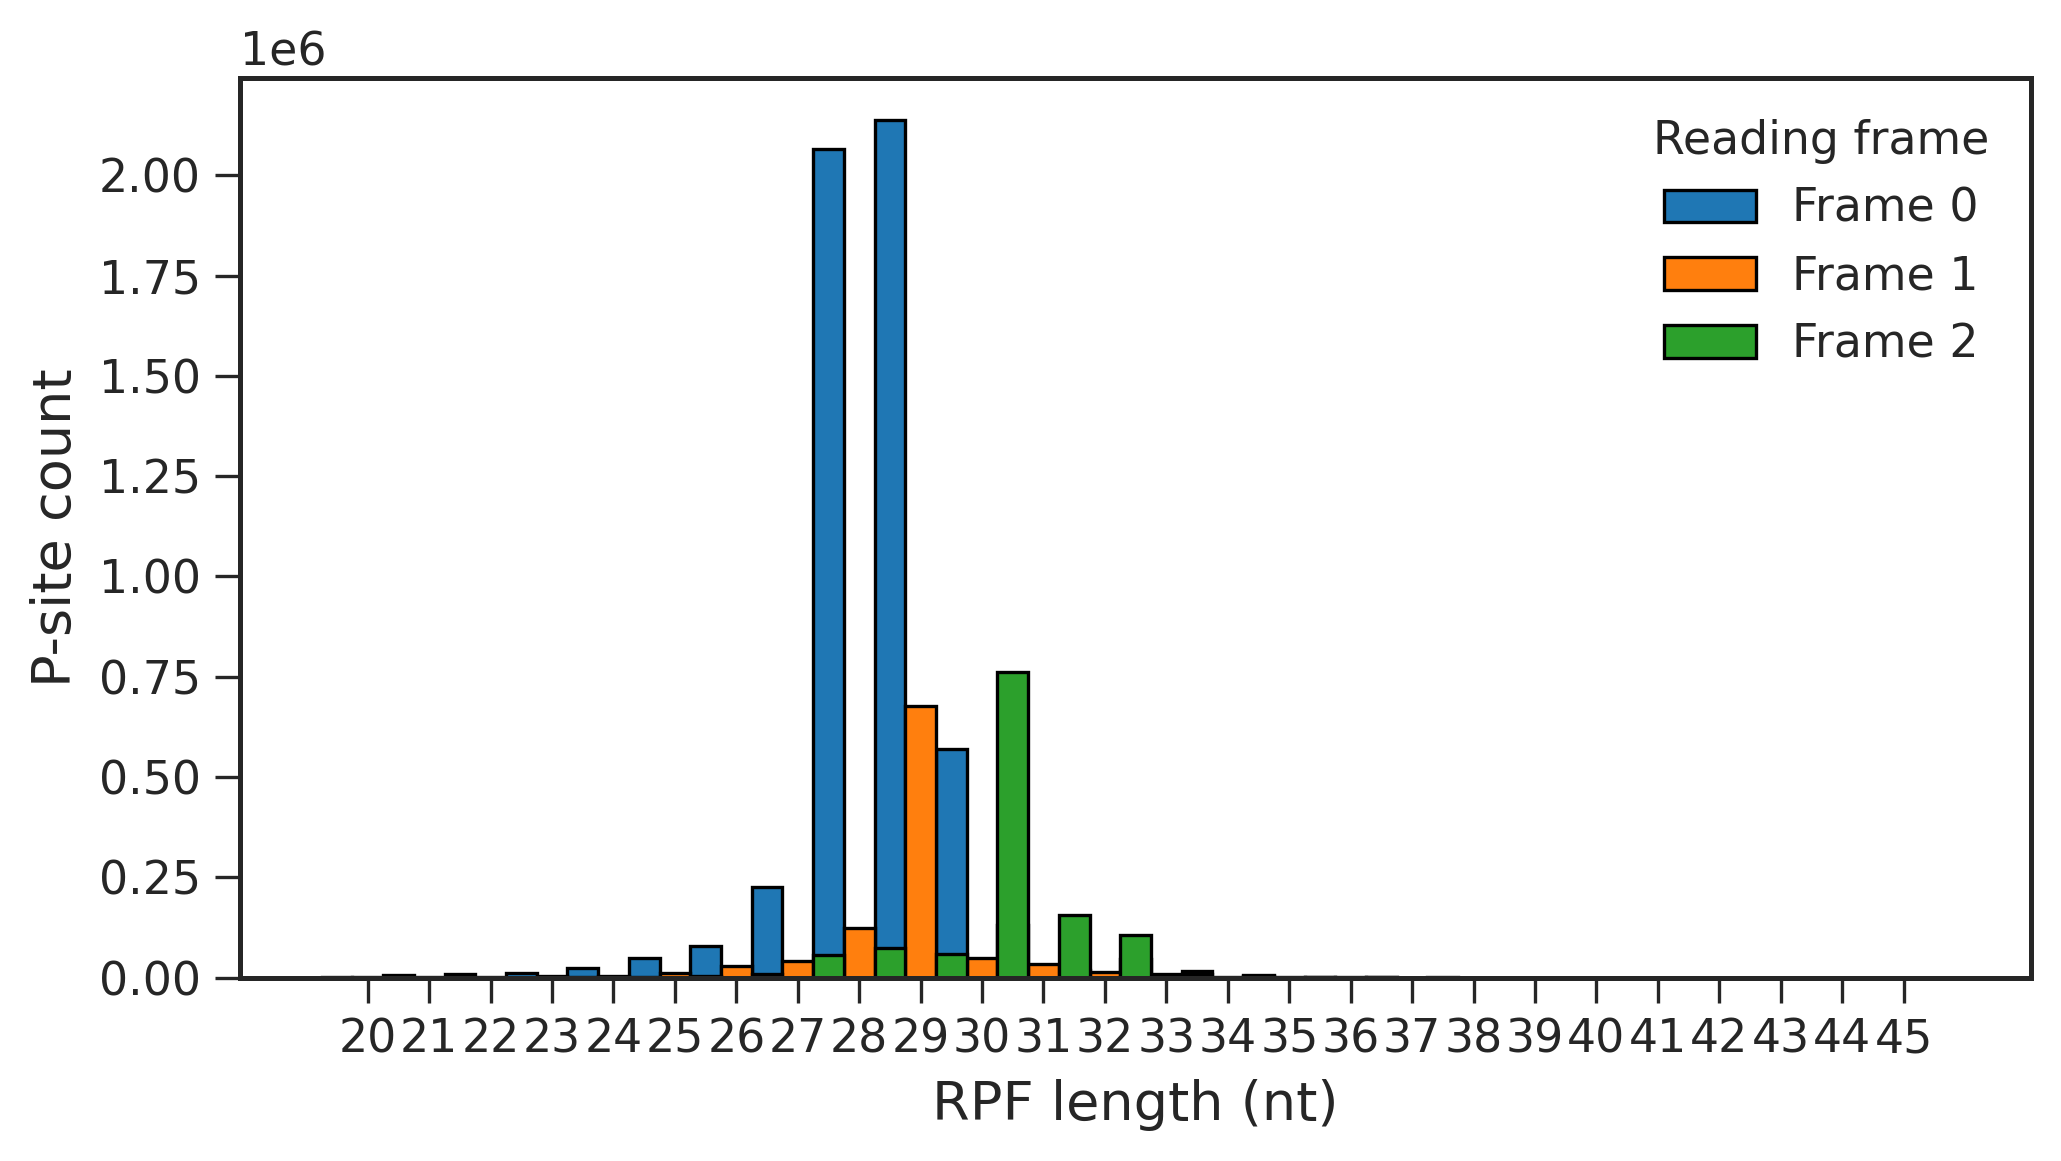

In [270]:
# ============================================
# RPF length distribution by reading frame
# ============================================

cds_psite = psite.loc[
    psite["psite_region"].str.lower() == "cds"
].copy()

cds_psite["frame"] = (
    cds_psite["psite_from_start"] % 3
)

length_frame = (
    cds_psite
    .groupby(["length", "frame"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[0, 1, 2], fill_value=0)
)

display(length_frame)

fig, ax = make_fig(w=7, h=4)

lengths = length_frame.index.to_numpy()

width = 0.5

ax.bar(
    lengths - width,
    length_frame[0],
    width=width,
    edgecolor="black",
    linewidth=0.8,
    label="Frame 0",
)

ax.bar(
    lengths,
    length_frame[1],
    width=width,
    edgecolor="black",
    linewidth=0.8,
    label="Frame 1",
)

ax.bar(
    lengths + width,
    length_frame[2],
    width=width,
    edgecolor="black",
    linewidth=0.8,
    label="Frame 2",
)

ax.set_xticks(lengths)
ax.set_xlabel("RPF length (nt)")
ax.set_ylabel("P-site count")

ax.legend(
    title="Reading frame",
    frameon=False,
)

plt.tight_layout()
plt.show()

,length,0,1,2,Frame_sum,P_sites,Difference
0,20,1920,682,229,2831,2831,0
1,21,5940,859,335,7134,7134,0
2,22,8961,3067,526,12554,12554,0
3,23,10757,4089,1162,16008,16008,0
4,24,25114,4879,2763,32756,32756,0
5,25,48011,12590,5138,65739,65739,0
6,26,79870,30235,10339,120444,120444,0
7,27,225084,41200,56605,322889,322889,0
8,28,2065704,124499,74644,2264847,2264847,0
9,29,2136751,678333,58478,2873562,2873562,0


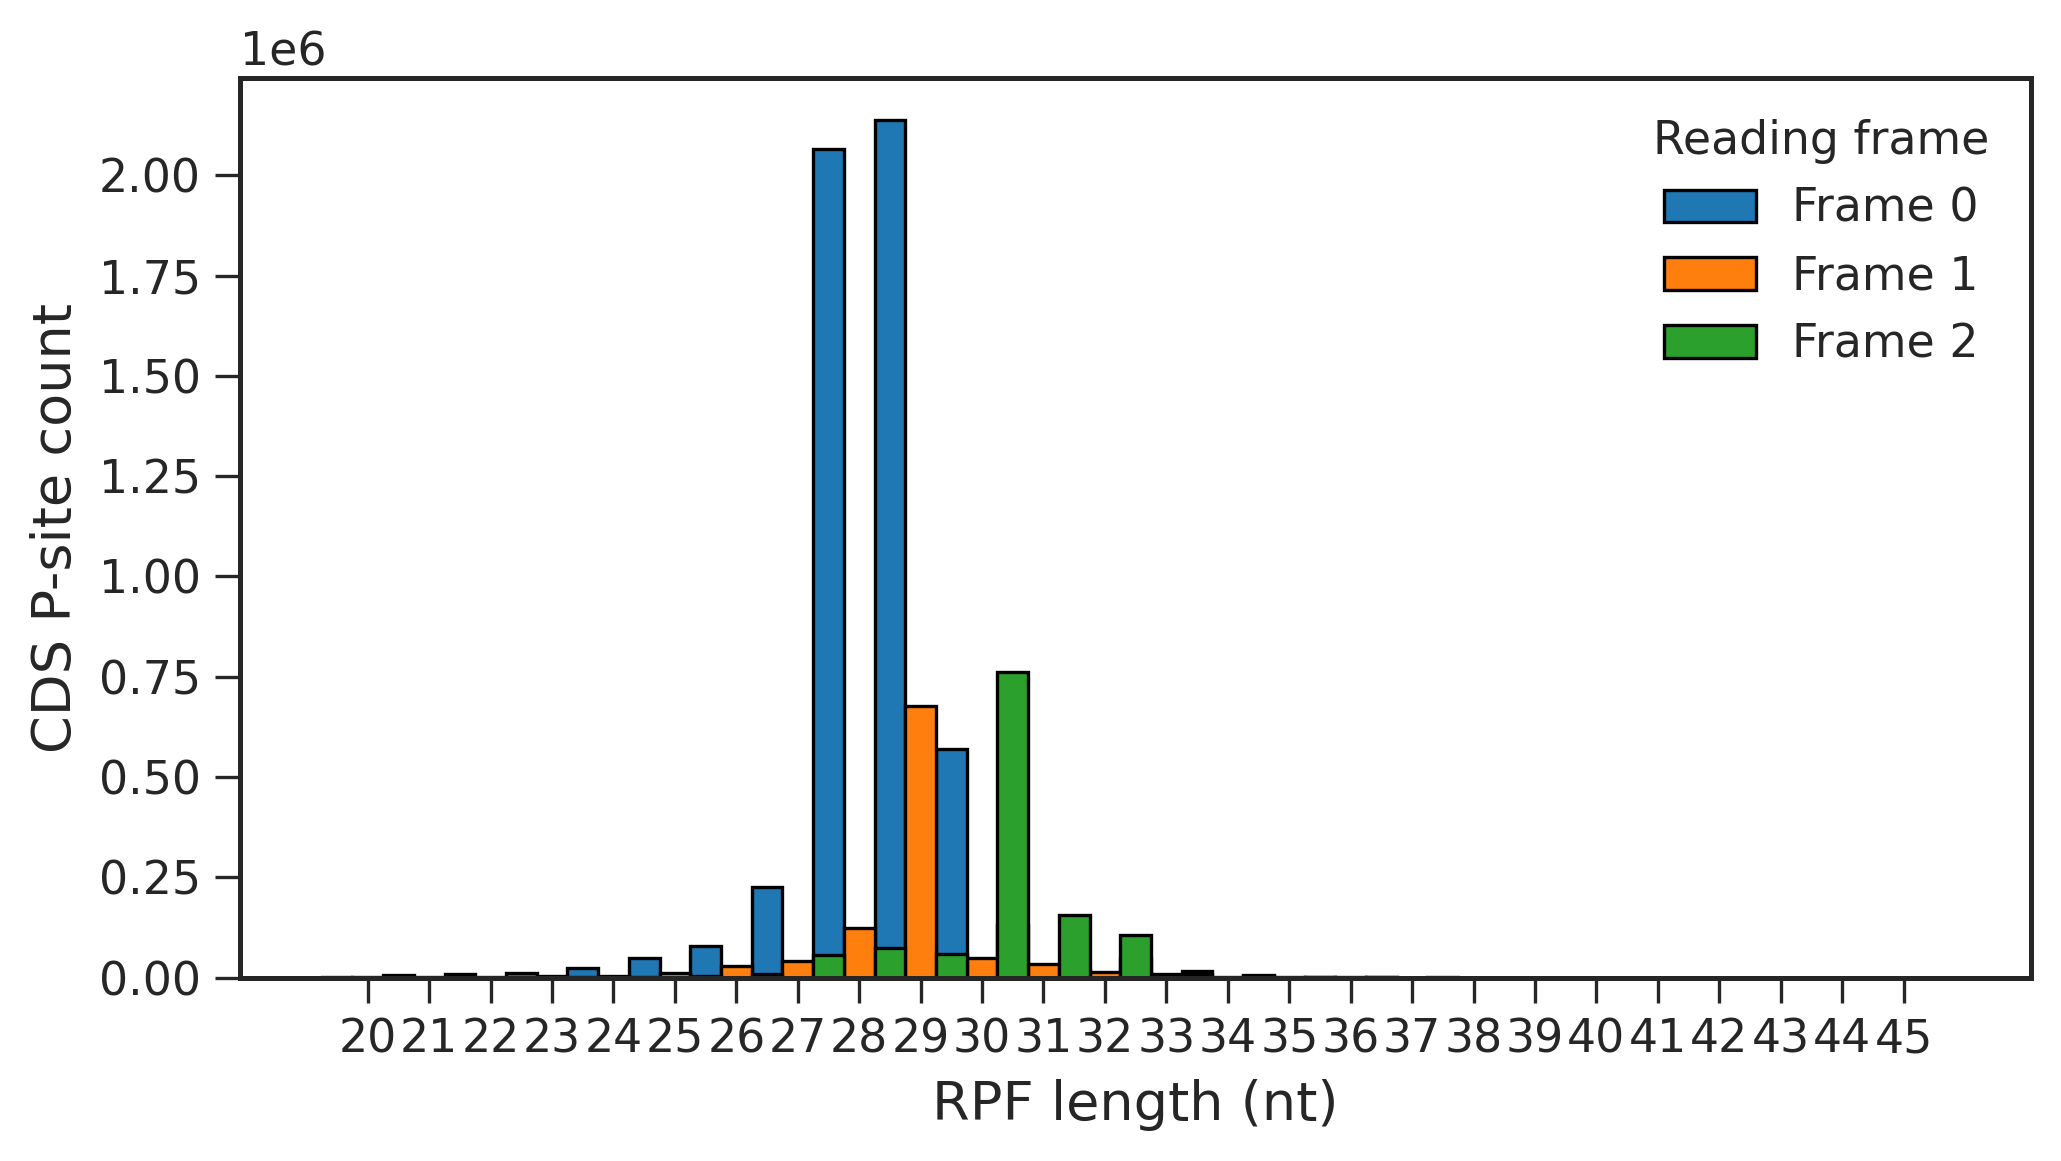

In [269]:
# ============================================
# RPF length distribution:
# total CDS P-sites and frame-specific P-sites
# ============================================

# Keep only P-sites located inside the CDS
cds_psite = psite.loc[
    psite["psite_region"].str.lower() == "cds"
].copy()

# Assign reading frame relative to the CDS start
cds_psite["frame"] = (
    cds_psite["psite_from_start"] % 3
)

# --------------------------------------------
# Total CDS P-sites per RPF length
# --------------------------------------------

length_total = (
    cds_psite["length"]
    .value_counts()
    .sort_index()
    .rename_axis("Length")
    .reset_index(name="P_sites")
)

# --------------------------------------------
# Frame-specific P-sites per RPF length
# --------------------------------------------

length_frame = (
    cds_psite
    .groupby(["length", "frame"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[0, 1, 2], fill_value=0)
)

# --------------------------------------------
# Verify that:
# total = Frame 0 + Frame 1 + Frame 2
# --------------------------------------------

comparison = length_frame.copy()

comparison["Frame_sum"] = (
    comparison[0]
    + comparison[1]
    + comparison[2]
)

comparison = (
    comparison
    .reset_index()
    .merge(
        length_total,
        left_on="length",
        right_on="Length",
        how="left",
    )
)

comparison["Difference"] = (
    comparison["P_sites"]
    - comparison["Frame_sum"]
)

display(comparison[[
    "length",
    0,
    1,
    2,
    "Frame_sum",
    "P_sites",
    "Difference",
]])

# --------------------------------------------
# Plot
# --------------------------------------------

fig, ax = make_fig(w=7, h=4)

lengths = length_frame.index.to_numpy()

width = 0.5

ax.bar(
    lengths - width,
    length_frame[0],
    width=width,
    edgecolor="black",
    linewidth=0.8,
    label="Frame 0",
)

ax.bar(
    lengths,
    length_frame[1],
    width=width,
    edgecolor="black",
    linewidth=0.8,
    label="Frame 1",
)

ax.bar(
    lengths + width,
    length_frame[2],
    width=width,
    edgecolor="black",
    linewidth=0.8,
    label="Frame 2",
)

ax.set_xticks(lengths)
ax.set_xlabel("RPF length (nt)")
ax.set_ylabel("CDS P-site count")

ax.legend(
    title="Reading frame",
    frameon=False,
)

plt.tight_layout()
plt.show()

,Frame,P_sites,Percentage,Frame_label
0,0,209309,71.498745,Frame 0
1,1,39219,13.396984,Frame 1
2,2,44217,15.104272,Frame 2


,Frame,P_sites,Percentage,Frame_label
0,0,359779,62.892819,Frame 0
1,1,115655,20.217603,Frame 1
2,2,96617,16.889578,Frame 2


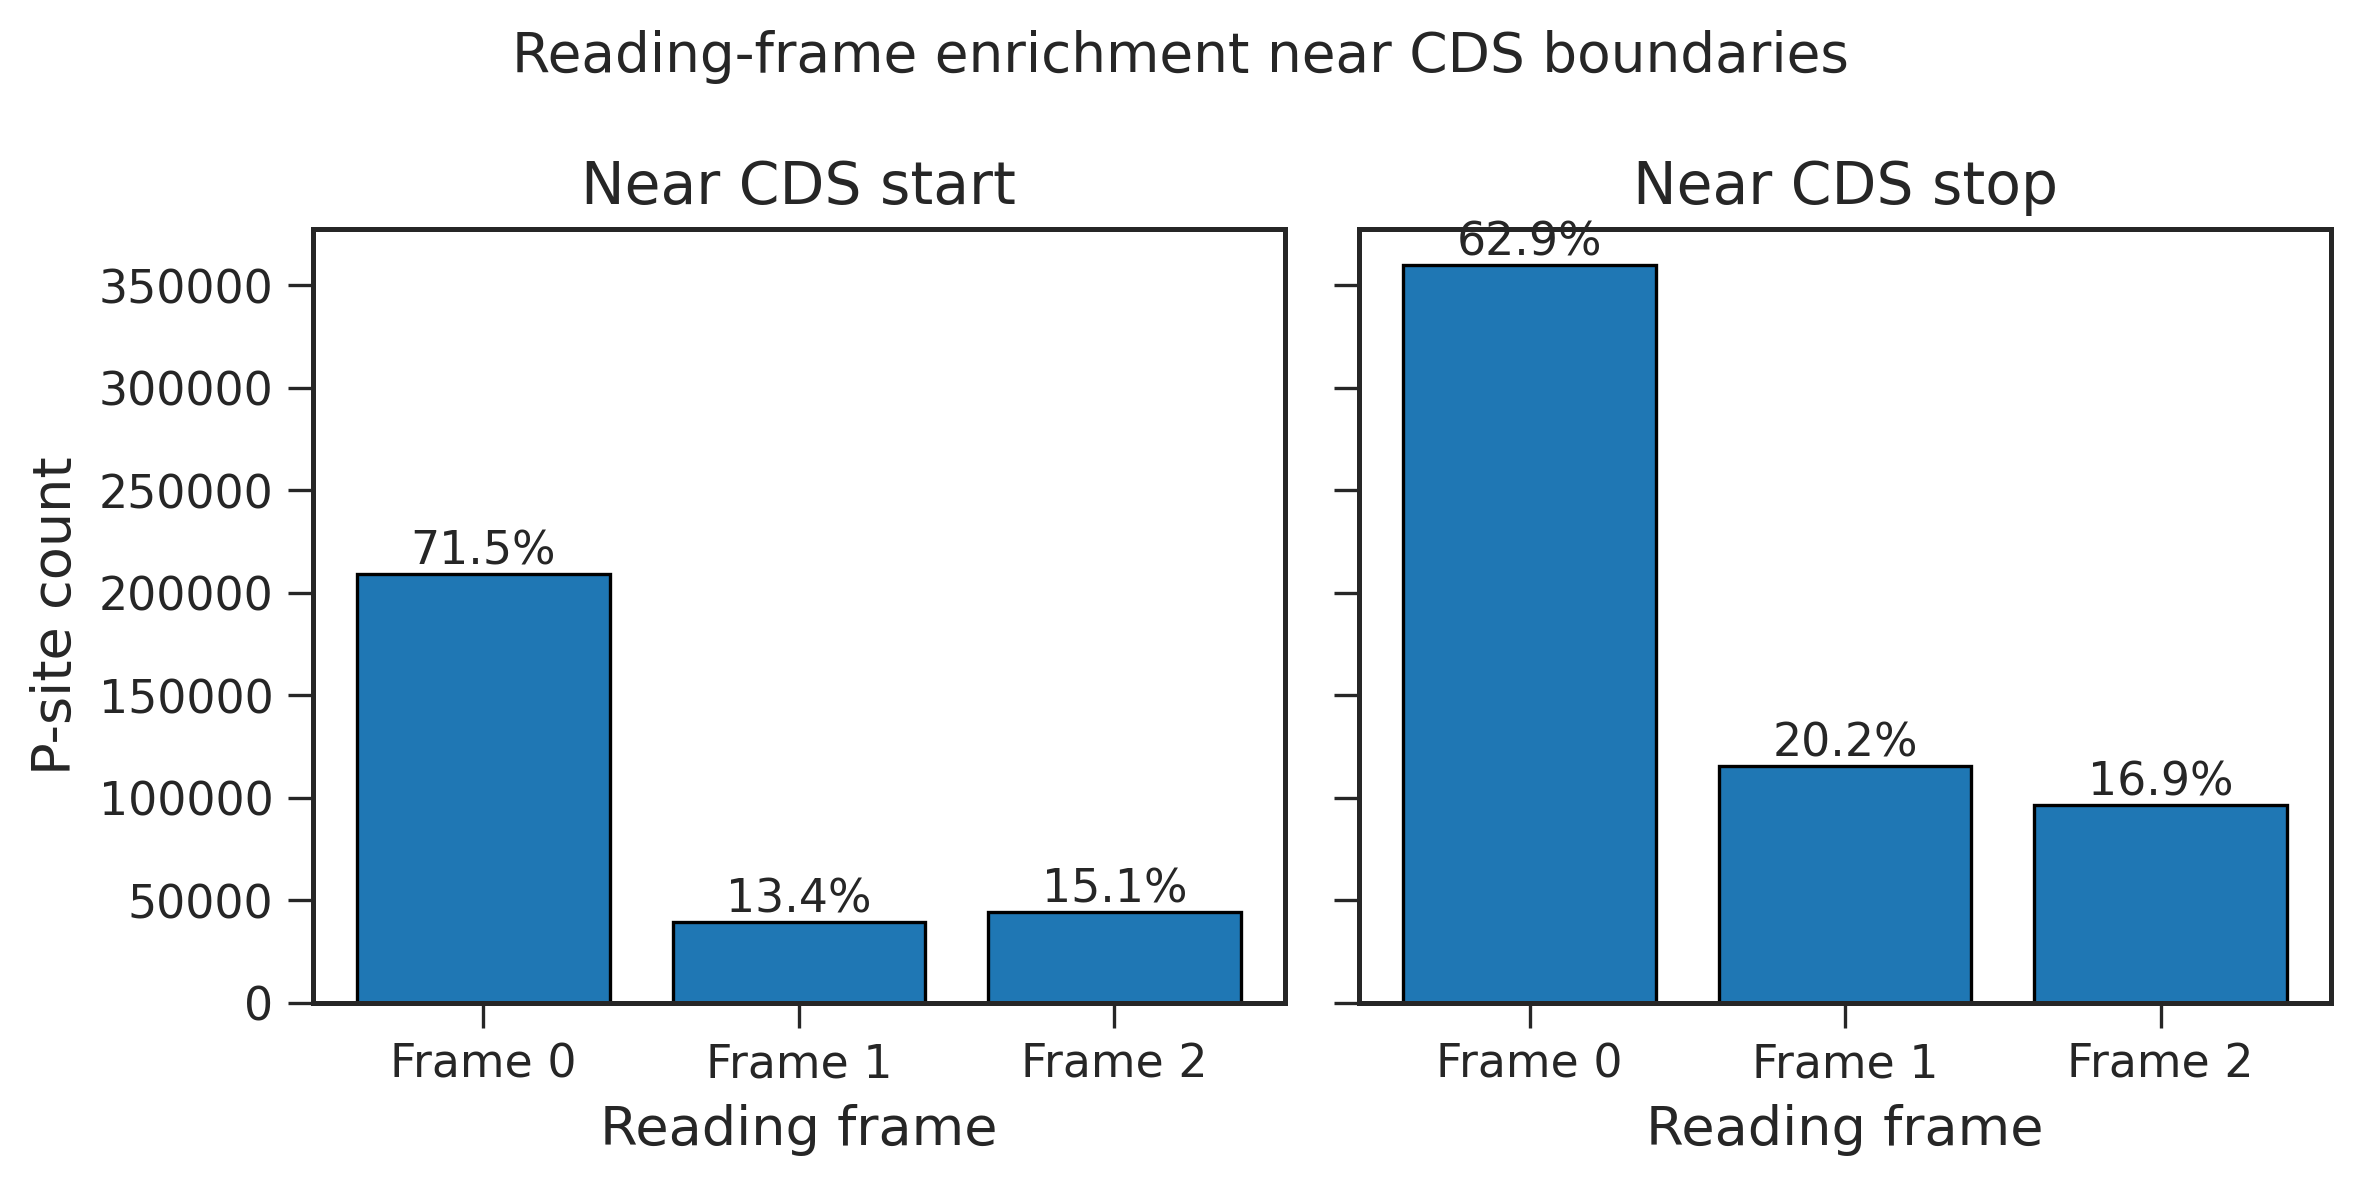

In [273]:
# ============================================
# Reading-frame enrichment near CDS boundaries
# ============================================

# --------------------------------------------
# CDS start window: 3 to 60 nt inside CDS
# Exclude position 0 because the initiation peak
# strongly dominates the distribution
# --------------------------------------------

start_frame = (
    psite.loc[
        (psite["psite_region"].str.lower() == "cds")
        & psite["psite_from_start"].between(3, 60)
    ]
    .assign(
        frame=lambda x: x["psite_from_start"] % 3
    )
    ["frame"]
    .value_counts()
    .reindex([0, 1, 2], fill_value=0)
    .rename_axis("Frame")
    .reset_index(name="P_sites")
)

start_frame["Percentage"] = (
    start_frame["P_sites"]
    / start_frame["P_sites"].sum()
    * 100
)

# --------------------------------------------
# CDS stop window: -60 to -3 nt inside CDS
# Frame remains defined relative to CDS start
# Exclude the stop boundary peak
# --------------------------------------------

stop_frame = (
    psite.loc[
        (psite["psite_region"].str.lower() == "cds")
        & psite["psite_from_stop"].between(-60, -3)
    ]
    .assign(
        frame=lambda x: x["psite_from_start"] % 3
    )
    ["frame"]
    .value_counts()
    .reindex([0, 1, 2], fill_value=0)
    .rename_axis("Frame")
    .reset_index(name="P_sites")
)

stop_frame["Percentage"] = (
    stop_frame["P_sites"]
    / stop_frame["P_sites"].sum()
    * 100
)

frame_labels = {
    0: "Frame 0",
    1: "Frame 1",
    2: "Frame 2",
}

start_frame["Frame_label"] = (
    start_frame["Frame"].map(frame_labels)
)

stop_frame["Frame_label"] = (
    stop_frame["Frame"].map(frame_labels)
)

display(start_frame)
display(stop_frame)

# --------------------------------------------
# Plot
# --------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8, 4),
    dpi=_PLOT_CFG["dpi"],
    sharey=True,
)

# CDS start
ax = axes[0]

bars = ax.bar(
    start_frame["Frame_label"],
    start_frame["P_sites"],
    edgecolor="black",
    linewidth=0.8,
)

for bar, pct in zip(
    bars,
    start_frame["Percentage"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_title("Near CDS start")
ax.set_xlabel("Reading frame")
ax.set_ylabel("P-site count")

# CDS stop
ax = axes[1]

bars = ax.bar(
    stop_frame["Frame_label"],
    stop_frame["P_sites"],
    edgecolor="black",
    linewidth=0.8,
)

for bar, pct in zip(
    bars,
    stop_frame["Percentage"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_title("Near CDS stop")
ax.set_xlabel("Reading frame")

fig.suptitle(
    "Reading-frame enrichment near CDS boundaries"
)

plt.tight_layout()
plt.show()

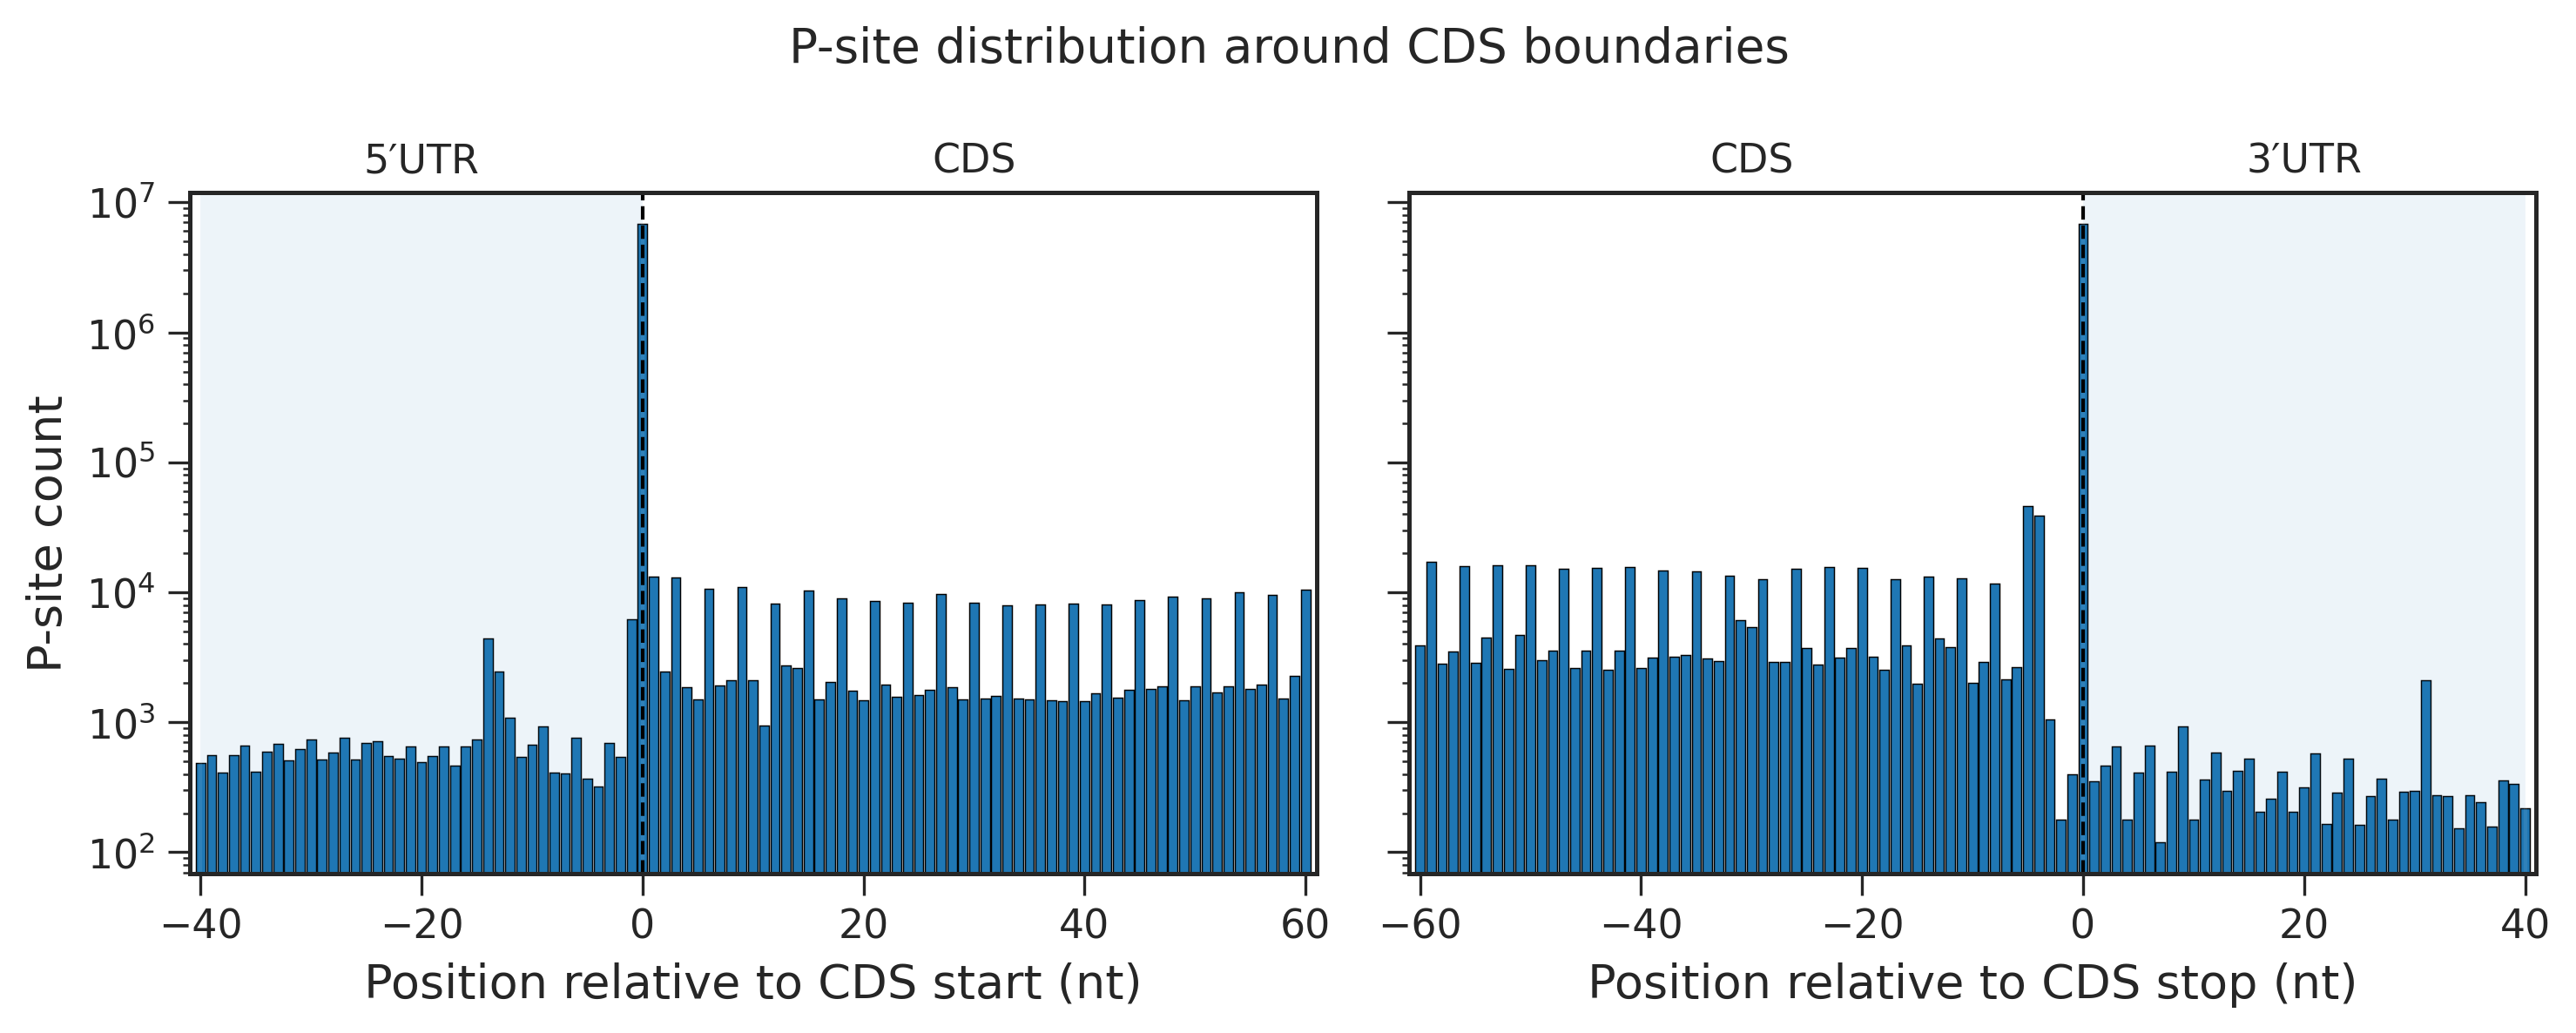

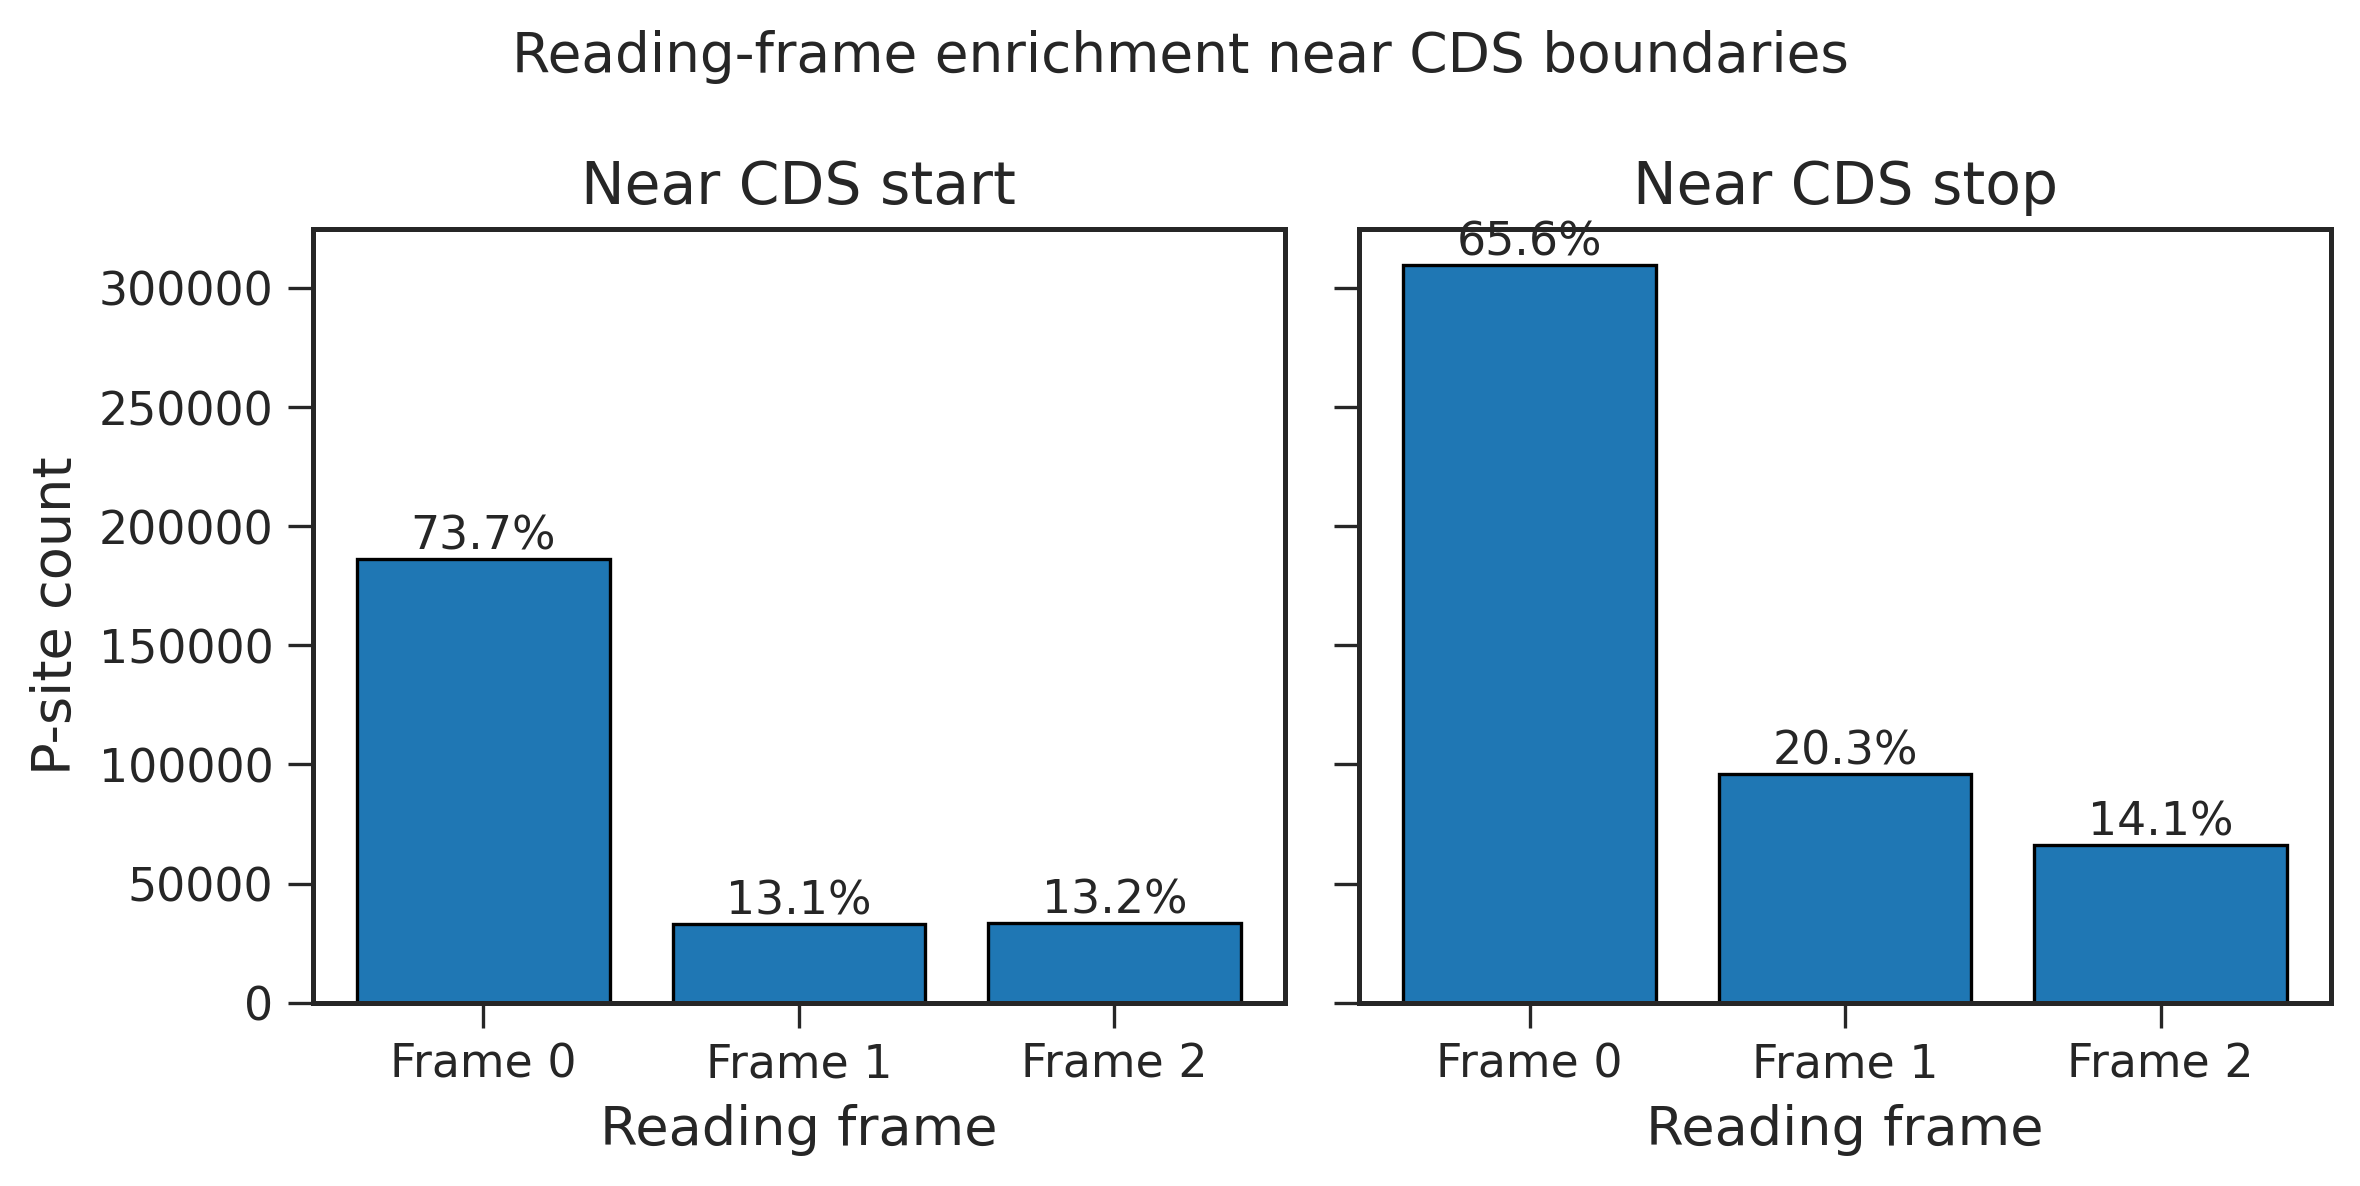

In [285]:
# ============================================
# Ribo-seq signal around CDS boundaries
#
# Figure 1:
#   5′UTR -> start -> CDS
#   CDS -> stop -> 3′UTR
#
# Figure 2:
#   Reading-frame enrichment inside CDS
#   near the start and stop boundaries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the dominant RPF lengths
periodic_psite = psite.loc[
    psite["length"].between(28, 30)
].copy()


# ============================================================
# FIGURE 1: P-site signal across both sides of each boundary
# ============================================================

# Start boundary: 5′UTR -> start -> CDS
start_profile = (
    periodic_psite.loc[
        periodic_psite["psite_from_start"].between(-40, 60)
    ]
    .groupby("psite_from_start")
    .size()
    .reindex(range(-40, 61), fill_value=0)
    .rename_axis("position")
    .reset_index(name="P_sites")
)

# Stop boundary: CDS -> stop -> 3′UTR
stop_profile = (
    periodic_psite.loc[
        periodic_psite["psite_from_stop"].between(-60, 40)
    ]
    .groupby("psite_from_stop")
    .size()
    .reindex(range(-60, 41), fill_value=0)
    .rename_axis("position")
    .reset_index(name="P_sites")
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    dpi=_PLOT_CFG["dpi"],
    sharey=True,
)

# -------------------------
# Start boundary
# -------------------------

ax = axes[0]

ax.bar(
    start_profile["position"],
    start_profile["P_sites"],
    width=0.85,
    edgecolor="black",
    linewidth=0.35,
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.axvspan(
    -40,
    0,
    alpha=0.08,
)

ax.set_xlim(-41, 61)
ax.set_yscale("log")

ax.set_xlabel("Position relative to CDS start (nt)")
ax.set_ylabel("P-site count")

ax.text(
    -20,
    1.03,
    "5′UTR",
    transform=ax.get_xaxis_transform(),
    ha="center",
)

ax.text(
    30,
    1.03,
    "CDS",
    transform=ax.get_xaxis_transform(),
    ha="center",
)

# -------------------------
# Stop boundary
# -------------------------

ax = axes[1]

ax.bar(
    stop_profile["position"],
    stop_profile["P_sites"],
    width=0.85,
    edgecolor="black",
    linewidth=0.35,
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.axvspan(
    0,
    40,
    alpha=0.08,
)

ax.set_xlim(-61, 41)
ax.set_yscale("log")

ax.set_xlabel("Position relative to CDS stop (nt)")

ax.text(
    -30,
    1.03,
    "CDS",
    transform=ax.get_xaxis_transform(),
    ha="center",
)

ax.text(
    20,
    1.03,
    "3′UTR",
    transform=ax.get_xaxis_transform(),
    ha="center",
)

fig.suptitle(
    "P-site distribution around CDS boundaries"
)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2: Reading-frame enrichment near CDS boundaries
#
# Frame is always defined from the CDS start.
# Only CDS P-sites are used.
# ============================================================

# Near CDS start:
# exclude the very large initiation peak at position 0
start_frame_data = periodic_psite.loc[
    (periodic_psite["psite_region"].str.lower() == "cds")
    & periodic_psite["psite_from_start"].between(3, 60)
].copy()

start_frame_data["frame"] = (
    start_frame_data["psite_from_start"] % 3
)

start_frame = (
    start_frame_data["frame"]
    .value_counts()
    .reindex([0, 1, 2], fill_value=0)
    .rename_axis("Frame")
    .reset_index(name="P_sites")
)

start_frame["Percentage"] = (
    start_frame["P_sites"]
    / start_frame["P_sites"].sum()
    * 100
)

# Near CDS stop:
# exclude the strong termination boundary
stop_frame_data = periodic_psite.loc[
    (periodic_psite["psite_region"].str.lower() == "cds")
    & periodic_psite["psite_from_stop"].between(-60, -3)
].copy()

# Biological frame remains relative to CDS start
stop_frame_data["frame"] = (
    stop_frame_data["psite_from_start"] % 3
)

stop_frame = (
    stop_frame_data["frame"]
    .value_counts()
    .reindex([0, 1, 2], fill_value=0)
    .rename_axis("Frame")
    .reset_index(name="P_sites")
)

stop_frame["Percentage"] = (
    stop_frame["P_sites"]
    / stop_frame["P_sites"].sum()
    * 100
)

frame_labels = {
    0: "Frame 0",
    1: "Frame 1",
    2: "Frame 2",
}

start_frame["Frame_label"] = (
    start_frame["Frame"].map(frame_labels)
)

stop_frame["Frame_label"] = (
    stop_frame["Frame"].map(frame_labels)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8, 4),
    dpi=_PLOT_CFG["dpi"],
    sharey=True,
)

# -------------------------
# Near CDS start
# -------------------------

ax = axes[0]

bars = ax.bar(
    start_frame["Frame_label"],
    start_frame["P_sites"],
    edgecolor="black",
    linewidth=0.8,
)

for bar, pct in zip(
    bars,
    start_frame["Percentage"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_title("Near CDS start")
ax.set_xlabel("Reading frame")
ax.set_ylabel("P-site count")

# -------------------------
# Near CDS stop
# -------------------------

ax = axes[1]

bars = ax.bar(
    stop_frame["Frame_label"],
    stop_frame["P_sites"],
    edgecolor="black",
    linewidth=0.8,
)

for bar, pct in zip(
    bars,
    stop_frame["Percentage"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_title("Near CDS stop")
ax.set_xlabel("Reading frame")

fig.suptitle(
    "Reading-frame enrichment near CDS boundaries"
)

plt.tight_layout()
plt.show()

In [240]:
import pandas as pd

cov = pd.read_csv(
    "/mnt/d/Ibnu/riboseq/AT/nfcore/full/ribowaltz/RIBO_FULL.codon_coverage_psite.tsv.gz",
    sep="\t",
)

print(cov.shape)

display(cov.head(20))

(25289212, 7)


,transcript,start,end,from_cds_start,from_cds_stop,region,RIBO_FULL
0,AT1G01010.1,0,3,-43,-472,5utr,0
1,AT1G01010.1,3,6,-42,-471,5utr,0
2,AT1G01010.1,6,9,-41,-470,5utr,0
3,AT1G01010.1,9,12,-40,-469,5utr,0
4,AT1G01010.1,12,15,-39,-468,5utr,0
5,AT1G01010.1,15,18,-38,-467,5utr,0
6,AT1G01010.1,18,21,-37,-466,5utr,0
7,AT1G01010.1,21,24,-36,-465,5utr,0
8,AT1G01010.1,24,27,-35,-464,5utr,0
9,AT1G01010.1,27,30,-34,-463,5utr,0


In [244]:
cov2 = pd.read_csv(
    "/mnt/d/Ibnu/riboseq/AT/nfcore/full/ribowaltz/RIBO_FULL.cds_plus42nt_minus27nt_coverage_psite.tsv.gz",
    sep="\t",
)

print(cov2.shape)

display(cov2.head(20))

(48323, 3)


,transcript,length_cds,RIBO_FULL
0,AT1G01010.1,1290,17
1,AT1G01020.1,738,8
2,AT1G01020.2,576,5
3,AT1G01020.3,711,7
4,AT1G01020.4,711,7
5,AT1G01020.5,597,7
6,AT1G01020.6,315,1
7,AT1G01030.1,1077,5
8,AT1G01030.2,1008,5
9,AT1G01040.1,5730,37


In [245]:
# ============================================
# Load codon-level P-site coverage
# ============================================

import pandas as pd

cov = pd.read_csv(
    "/mnt/d/Ibnu/riboseq/AT/nfcore/full/ribowaltz/RIBO_FULL.codon_coverage_psite.tsv.gz",
    sep="\t",
)

print(cov.shape)
cov.head()

(25289212, 7)


,transcript,start,end,from_cds_start,from_cds_stop,region,RIBO_FULL
0,AT1G01010.1,0,3,-43,-472,5utr,0
1,AT1G01010.1,3,6,-42,-471,5utr,0
2,AT1G01010.1,6,9,-41,-470,5utr,0
3,AT1G01010.1,9,12,-40,-469,5utr,0
4,AT1G01010.1,12,15,-39,-468,5utr,0


In [246]:
# ============================================
# Window around translation start
# ============================================

window = cov[
    cov["from_cds_start"].between(-40, 120)
].copy()

print(window.shape)

(6292724, 7)


In [247]:
# ============================================
# Average metagene signal
# ============================================

meta = (
    window
    .groupby("from_cds_start", as_index=False)["RIBO_FULL"]
    .sum()
)

display(meta.head(20))
display(meta.tail(20))

,from_cds_start,RIBO_FULL
0,-40,870
1,-39,905
2,-38,1087
3,-37,986
4,-36,1199
5,-35,909
6,-34,1287
7,-33,1006
8,-32,1132
9,-31,878


,from_cds_start,RIBO_FULL
141,101,29427
142,102,23434
143,103,20905
144,104,20987
145,105,21333
146,106,20389
147,107,20284
148,108,20542
149,109,19756
150,110,19909


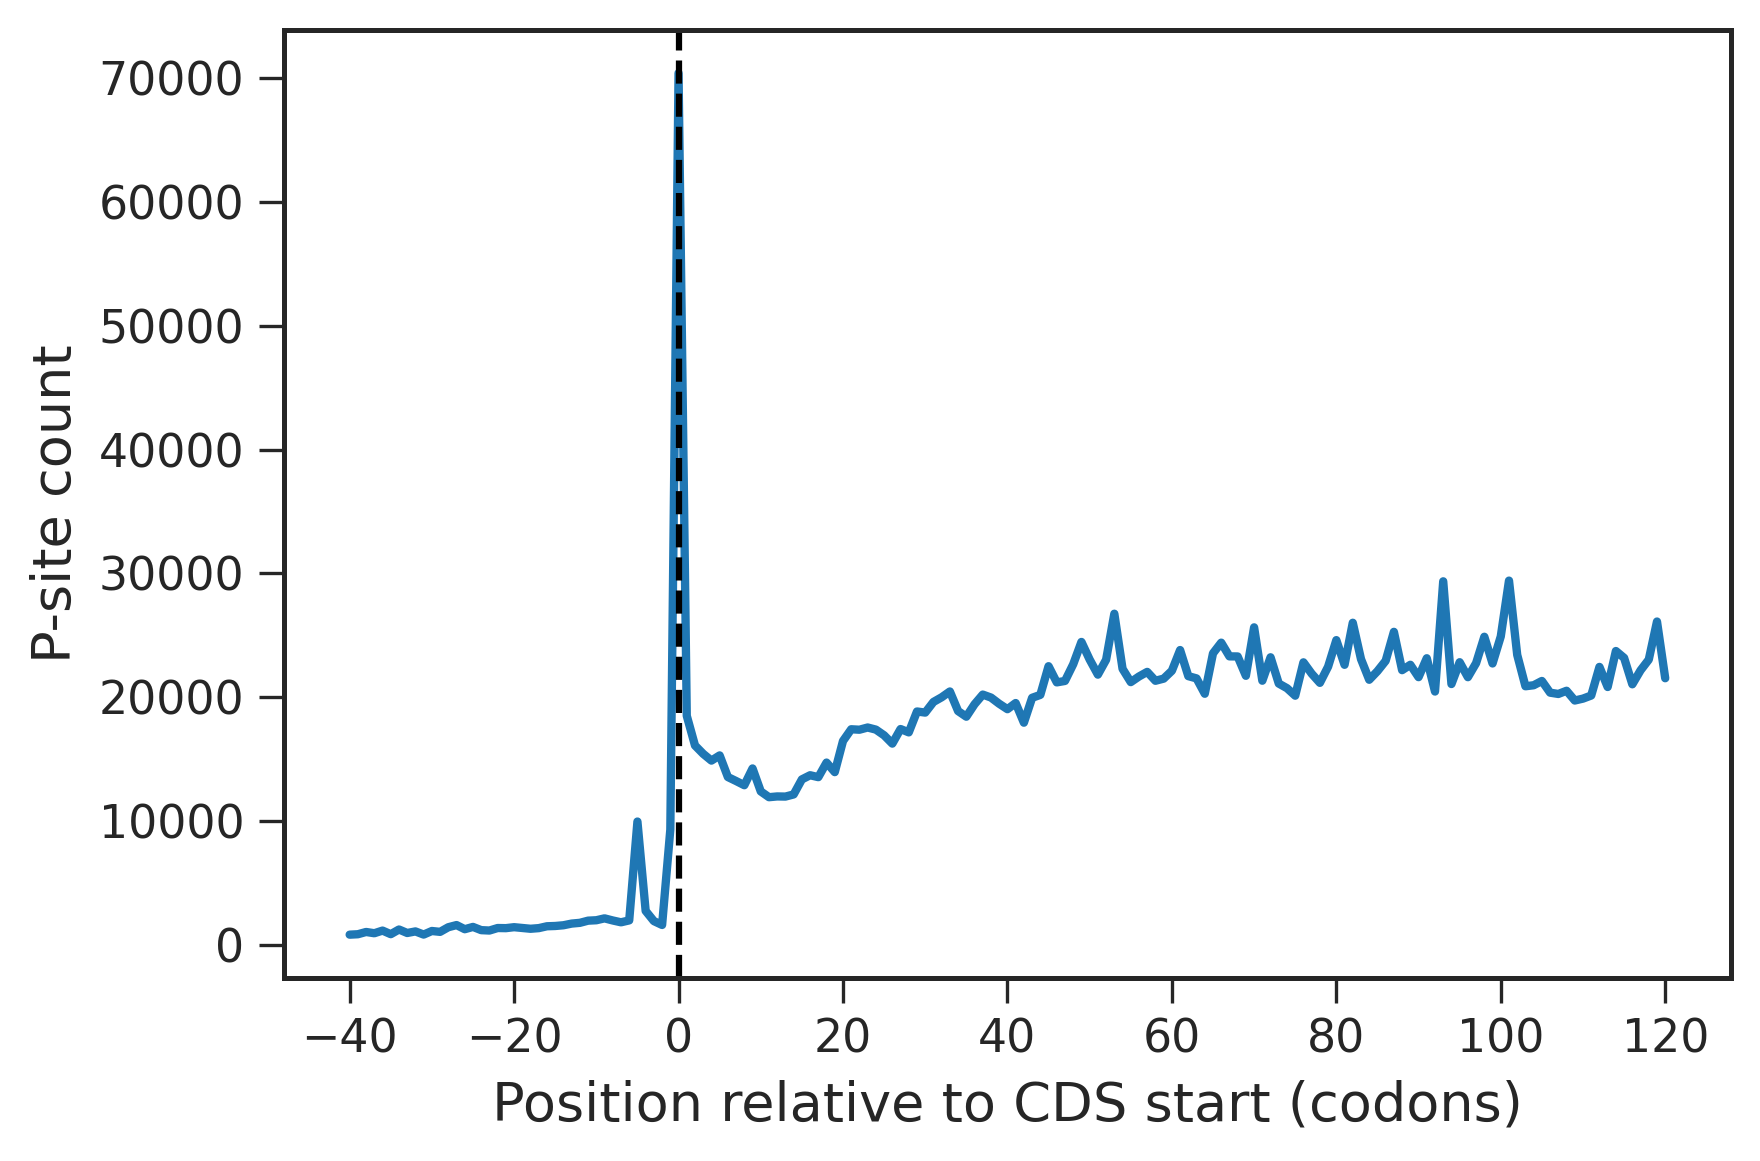

In [248]:
# ============================================
# Metagene profile around CDS start
# ============================================

fig, ax = make_fig(w=6, h=4)

ax.plot(
    meta["from_cds_start"],
    meta["RIBO_FULL"],
    linewidth=2,
)

ax.axvline(
    0,
    linestyle="--",
    color="black",
)

ax.set_xlabel("Position relative to CDS start (codons)")
ax.set_ylabel("P-site count")

plt.tight_layout()
plt.show()

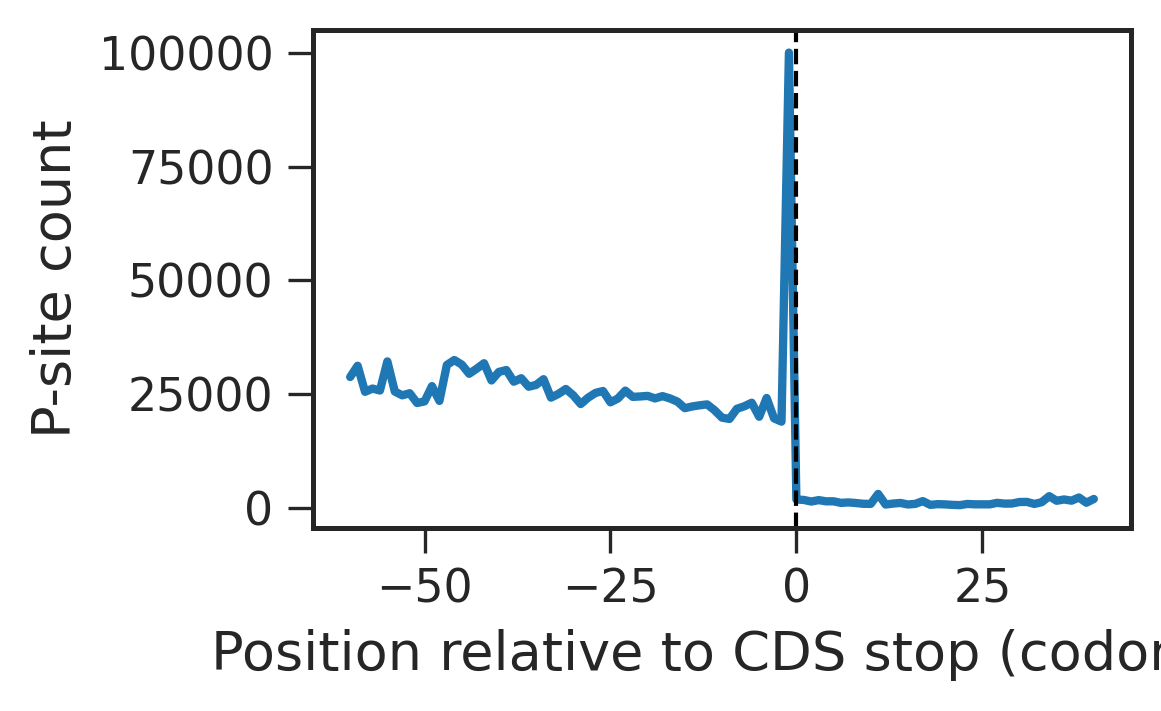

In [287]:
# ============================================
# Metagene profile around CDS stop
# ============================================

stop_window = cov.loc[
    cov["from_cds_stop"].between(-60, 40)
].copy()

stop_meta = (
    stop_window
    .groupby("from_cds_stop", as_index=False)["RIBO_FULL"]
    .sum()
)

fig, ax = make_fig(w=4, h=2.5)

ax.plot(
    stop_meta["from_cds_stop"],
    stop_meta["RIBO_FULL"],
    linewidth=2,
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel("Position relative to CDS stop (codons)")
ax.set_ylabel("P-site count")

plt.tight_layout()
plt.show()

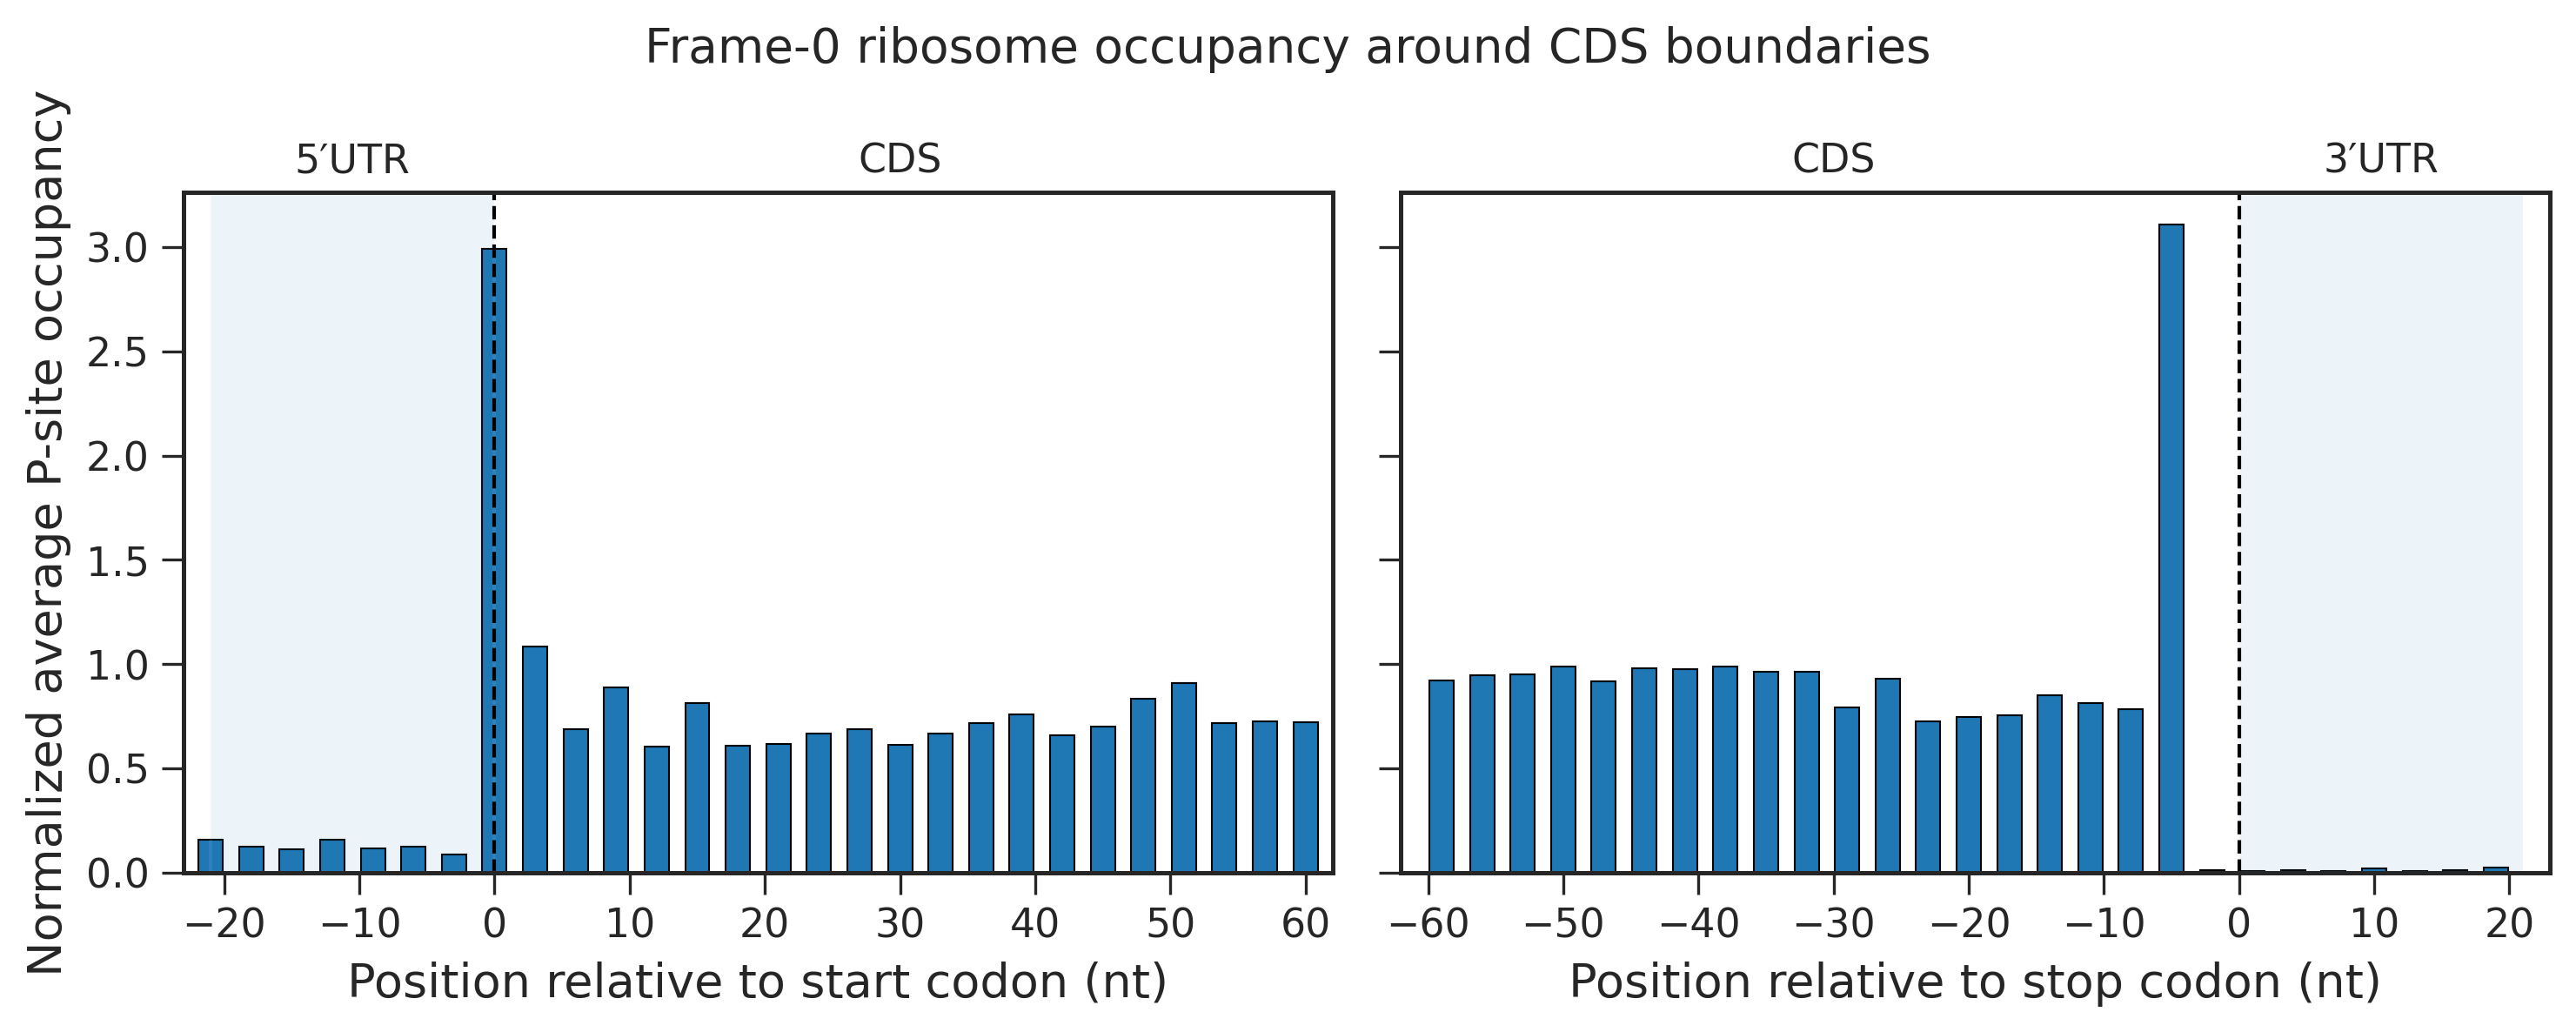

In [289]:
# ============================================
# Frame-0 metagene around CDS boundaries
#
# Start panel: 5′UTR -> AUG -> CDS
# Stop panel:  CDS -> STOP -> 3′UTR
#
# Similar logic to the reference figure:
# one bar every 3 nt, using Frame 0 P-sites only
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------
# 1. Select dominant RPF lengths
# --------------------------------------------

rpf = psite.loc[
    psite["length"].between(28, 30)
].copy()


# --------------------------------------------
# 2. Define the biological reading frame
#
# Frame is always calculated relative to
# the annotated CDS start.
# --------------------------------------------

rpf["frame"] = (
    rpf["psite_from_start"] % 3
)

frame0 = rpf.loc[
    rpf["frame"] == 0
].copy()


# --------------------------------------------
# 3. Calculate mean CDS occupancy per transcript
#
# This is used to normalize each transcript
# before averaging the metagene profile.
# --------------------------------------------

transcript_info = (
    frame0
    .groupby("transcript", as_index=False)
    .agg(
        cds_start=("cds_start", "first"),
        cds_stop=("cds_stop", "first"),
    )
)

transcript_info["cds_length_nt"] = (
    transcript_info["cds_stop"]
    - transcript_info["cds_start"]
    + 1
)

transcript_info["cds_codons"] = (
    transcript_info["cds_length_nt"] // 3
)

cds_frame0_counts = (
    frame0.loc[
        frame0["psite_region"].str.lower() == "cds"
    ]
    .groupby("transcript")
    .size()
    .rename("cds_frame0_psites")
    .reset_index()
)

transcript_norm = (
    transcript_info
    .merge(
        cds_frame0_counts,
        on="transcript",
        how="left",
    )
)

transcript_norm["cds_frame0_psites"] = (
    transcript_norm["cds_frame0_psites"]
    .fillna(0)
)

transcript_norm["mean_cds_occupancy"] = (
    transcript_norm["cds_frame0_psites"]
    / transcript_norm["cds_codons"]
)

# Keep transcripts with measurable CDS occupancy
transcript_norm = transcript_norm.loc[
    transcript_norm["mean_cds_occupancy"] > 0
].copy()

valid_transcripts = (
    transcript_norm["transcript"]
    .unique()
)

normalization = (
    transcript_norm
    .set_index("transcript")["mean_cds_occupancy"]
)


# ============================================
# 4. Start-codon metagene
#    -21 to +60 nt
# ============================================

start_positions = np.arange(
    -21,
    61,
    3,
)

start_data = frame0.loc[
    frame0["transcript"].isin(valid_transcripts)
    & frame0["psite_from_start"].between(
        start_positions.min(),
        start_positions.max(),
    )
].copy()

start_counts = (
    start_data
    .groupby(
        ["transcript", "psite_from_start"]
    )
    .size()
    .rename("P_sites")
)

start_index = pd.MultiIndex.from_product(
    [
        valid_transcripts,
        start_positions,
    ],
    names=[
        "transcript",
        "position",
    ],
)

start_counts = (
    start_counts
    .reindex(
        start_index,
        fill_value=0,
    )
    .reset_index()
)

start_counts["normalized_occupancy"] = (
    start_counts["P_sites"]
    / start_counts["transcript"].map(normalization)
)

start_profile = (
    start_counts
    .groupby(
        "position",
        as_index=False,
    )
    ["normalized_occupancy"]
    .mean()
)


# ============================================
# 5. Stop-codon metagene
#    -60 to +21 nt
#
# Frame 0 remains defined from CDS start.
# ============================================

stop_data = frame0.loc[
    frame0["transcript"].isin(valid_transcripts)
    & frame0["psite_from_stop"].between(
        -60,
        21,
    )
].copy()

# Determine the actual Frame-0 positions present
# relative to the stop boundary.
stop_positions = np.sort(
    stop_data["psite_from_stop"]
    .unique()
)

stop_counts = (
    stop_data
    .groupby(
        ["transcript", "psite_from_stop"]
    )
    .size()
    .rename("P_sites")
)

stop_index = pd.MultiIndex.from_product(
    [
        valid_transcripts,
        stop_positions,
    ],
    names=[
        "transcript",
        "position",
    ],
)

stop_counts = (
    stop_counts
    .reindex(
        stop_index,
        fill_value=0,
    )
    .reset_index()
)

stop_counts["normalized_occupancy"] = (
    stop_counts["P_sites"]
    / stop_counts["transcript"].map(normalization)
)

stop_profile = (
    stop_counts
    .groupby(
        "position",
        as_index=False,
    )
    ["normalized_occupancy"]
    .mean()
)


# ============================================
# 6. Plot
# ============================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    dpi=_PLOT_CFG["dpi"],
    sharey=True,
)


# --------------------------------------------
# Start panel
# 5′UTR -> AUG -> CDS
# --------------------------------------------

ax = axes[0]

ax.bar(
    start_profile["position"],
    start_profile["normalized_occupancy"],
    width=1.8,
    edgecolor="black",
    linewidth=0.5,
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.axvspan(
    start_positions.min(),
    0,
    alpha=0.08,
)

ax.set_xlim(
    start_positions.min() - 2,
    start_positions.max() + 2,
)

ax.set_xlabel(
    "Position relative to start codon (nt)"
)

ax.set_ylabel(
    "Normalized average P-site occupancy"
)

ax.text(
    -10.5,
    1.03,
    "5′UTR",
    transform=ax.get_xaxis_transform(),
    ha="center",
)

ax.text(
    30,
    1.03,
    "CDS",
    transform=ax.get_xaxis_transform(),
    ha="center",
)


# --------------------------------------------
# Stop panel
# CDS -> STOP -> 3′UTR
# --------------------------------------------

ax = axes[1]

ax.bar(
    stop_profile["position"],
    stop_profile["normalized_occupancy"],
    width=1.8,
    edgecolor="black",
    linewidth=0.5,
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.axvspan(
    0,
    21,
    alpha=0.08,
)

ax.set_xlim(
    -62,
    23,
)

ax.set_xlabel(
    "Position relative to stop codon (nt)"
)

ax.text(
    -30,
    1.03,
    "CDS",
    transform=ax.get_xaxis_transform(),
    ha="center",
)

ax.text(
    10.5,
    1.03,
    "3′UTR",
    transform=ax.get_xaxis_transform(),
    ha="center",
)


fig.suptitle(
    "Frame-0 ribosome occupancy around CDS boundaries"
)

plt.tight_layout()
plt.show()

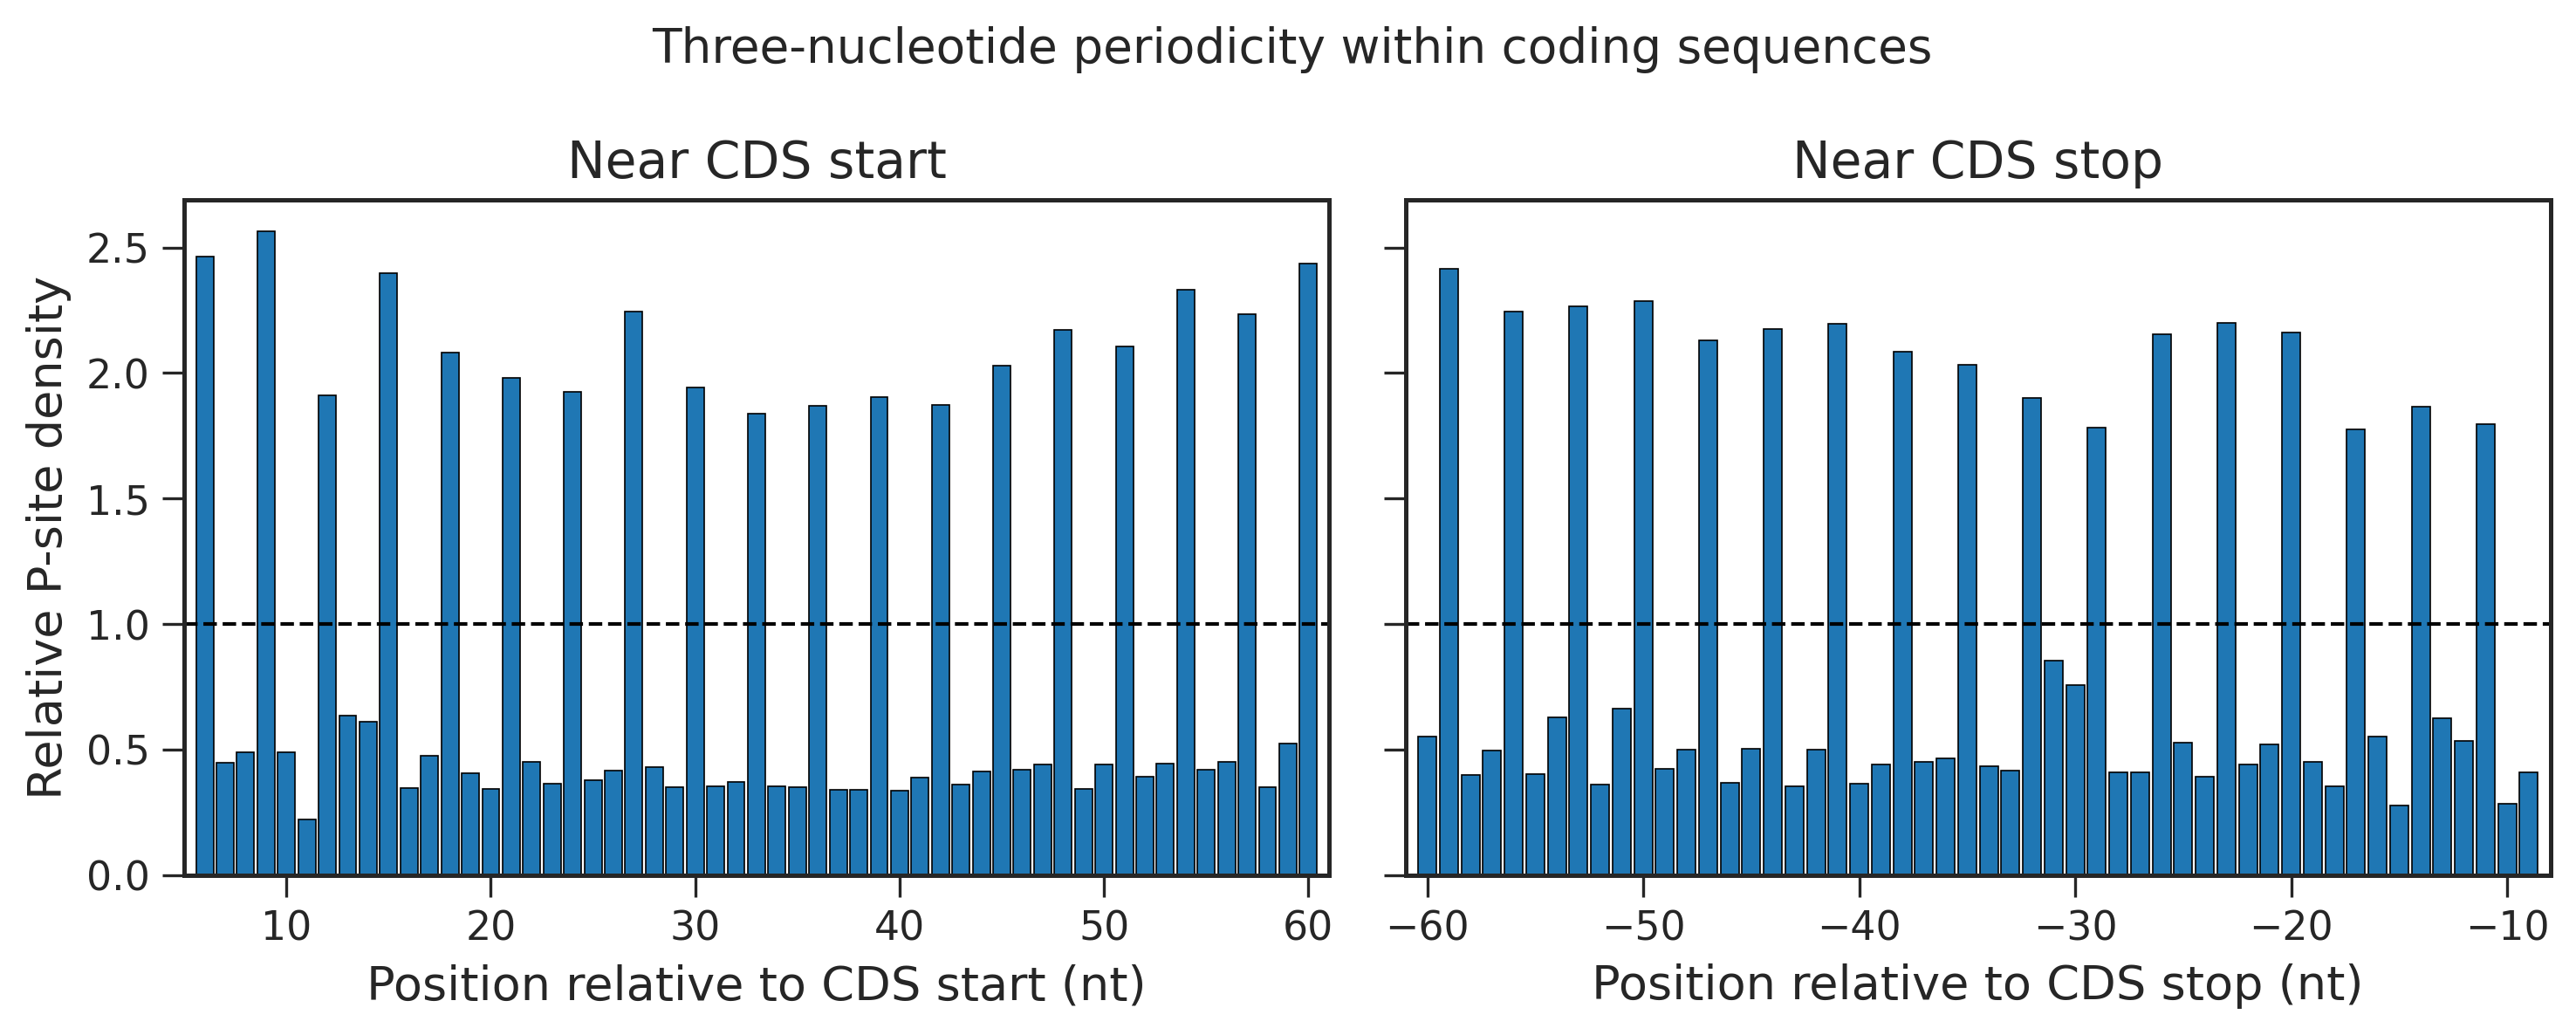

In [290]:
# ============================================
# Three-nucleotide periodicity around CDS boundaries
#
# All P-site positions are retained.
# No frame filtering and no frame coloring.
#
# Start panel: +6 to +60 nt inside CDS
# Stop panel:  -60 to -9 nt inside CDS
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# Use the dominant RPF lengths
periodic_psite = psite.loc[
    psite["length"].between(28, 30)
].copy()

# --------------------------------------------
# Near CDS start
#
# Exclude positions 0–5 because the strong
# initiation peak can dominate the plot.
# --------------------------------------------

start_periodicity = (
    periodic_psite.loc[
        (periodic_psite["psite_region"].str.lower() == "cds")
        & periodic_psite["psite_from_start"].between(6, 60)
    ]
    .groupby("psite_from_start")
    .size()
    .reindex(range(6, 61), fill_value=0)
    .rename_axis("position")
    .reset_index(name="P_sites")
)

# Normalize to the mean count in this window
start_periodicity["relative_density"] = (
    start_periodicity["P_sites"]
    / start_periodicity["P_sites"].mean()
)

# --------------------------------------------
# Near CDS stop
#
# Exclude positions close to the stop boundary
# because termination-associated peaks can dominate.
# --------------------------------------------

stop_periodicity = (
    periodic_psite.loc[
        (periodic_psite["psite_region"].str.lower() == "cds")
        & periodic_psite["psite_from_stop"].between(-60, -9)
    ]
    .groupby("psite_from_stop")
    .size()
    .reindex(range(-60, -8), fill_value=0)
    .rename_axis("position")
    .reset_index(name="P_sites")
)

# Normalize to the mean count in this window
stop_periodicity["relative_density"] = (
    stop_periodicity["P_sites"]
    / stop_periodicity["P_sites"].mean()
)

# --------------------------------------------
# Plot
# --------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    dpi=_PLOT_CFG["dpi"],
    sharey=True,
)

# ============================================
# Near CDS start
# ============================================

ax = axes[0]

ax.bar(
    start_periodicity["position"],
    start_periodicity["relative_density"],
    width=0.85,
    edgecolor="black",
    linewidth=0.4,
)

ax.axhline(
    1,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.set_xlim(5, 61)
ax.set_xlabel("Position relative to CDS start (nt)")
ax.set_ylabel("Relative P-site density")
ax.set_title("Near CDS start")

# ============================================
# Near CDS stop
# ============================================

ax = axes[1]

ax.bar(
    stop_periodicity["position"],
    stop_periodicity["relative_density"],
    width=0.85,
    edgecolor="black",
    linewidth=0.4,
)

ax.axhline(
    1,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.set_xlim(-61, -8)
ax.set_xlabel("Position relative to CDS stop (nt)")
ax.set_title("Near CDS stop")

fig.suptitle(
    "Three-nucleotide periodicity within coding sequences"
)

plt.tight_layout()
plt.show()